#   Traitement de données du fichier PDF  with Open BC

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *
# %matplotlib widget
import sciplotlib.style as spstyle
plt.rcParams['font.weight'] = 'normal' 
plt.rcParams['font.family'] = 'Arial' 
plt.rcParams['pdf.fonttype'] = 42

L1 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[1]

lengthtab = L1 * L2
nbins = 100
Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8,8])
Tnmax = np.array([80,45,50,50,50,50,50, 80,80,80,80,80,80,80])
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
""" folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
Tvar = [read_parameters(folder)[2] for folder in folderpath]

folderpathbis = folderpath.copy()
for i in range(1,7):
    folderpathbis[i-1] = "/data1/DATA_Duplat/Brut/PDF/PD7n{}".format(i)


##  Size

In [2]:

results_s = Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                    for  folder in folderpath)

Thisto_s, Tbins_s, Tnonzero_s, Tmean_s,Tnbins_s = zip(*results_s)

0.96545763582405
0.9971726928826957
0.9940950079772213
0.9970879131270517
0.9967105205796035
0.9906659255469019
0.9877020531728582
0.9272213838997168
0.9122521887346848
0.9705872766834267
0.9174095398449836
0.9057453446744788
0.8991641398725068
0.8933054895985362
err:  [0.00288374 0.00992591 0.02418754 0.01829912 0.00759423 0.00672122
 0.00839195 0.01137762 0.00585009 0.00236216 0.00331863 0.00583675
 0.00767259 0.01179889]


/tmp/ipykernel_11385/3133955170.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]


[1.         1.05747756 0.9375964  0.97918421 0.99085124 0.93036963
 0.752122   0.38969384 0.29504355 0.25913365 0.22974635 0.19902045
 0.16170999 0.13450907]
a = -14.05, b = 1.23
a2 = -0.32, b2 = 0.32


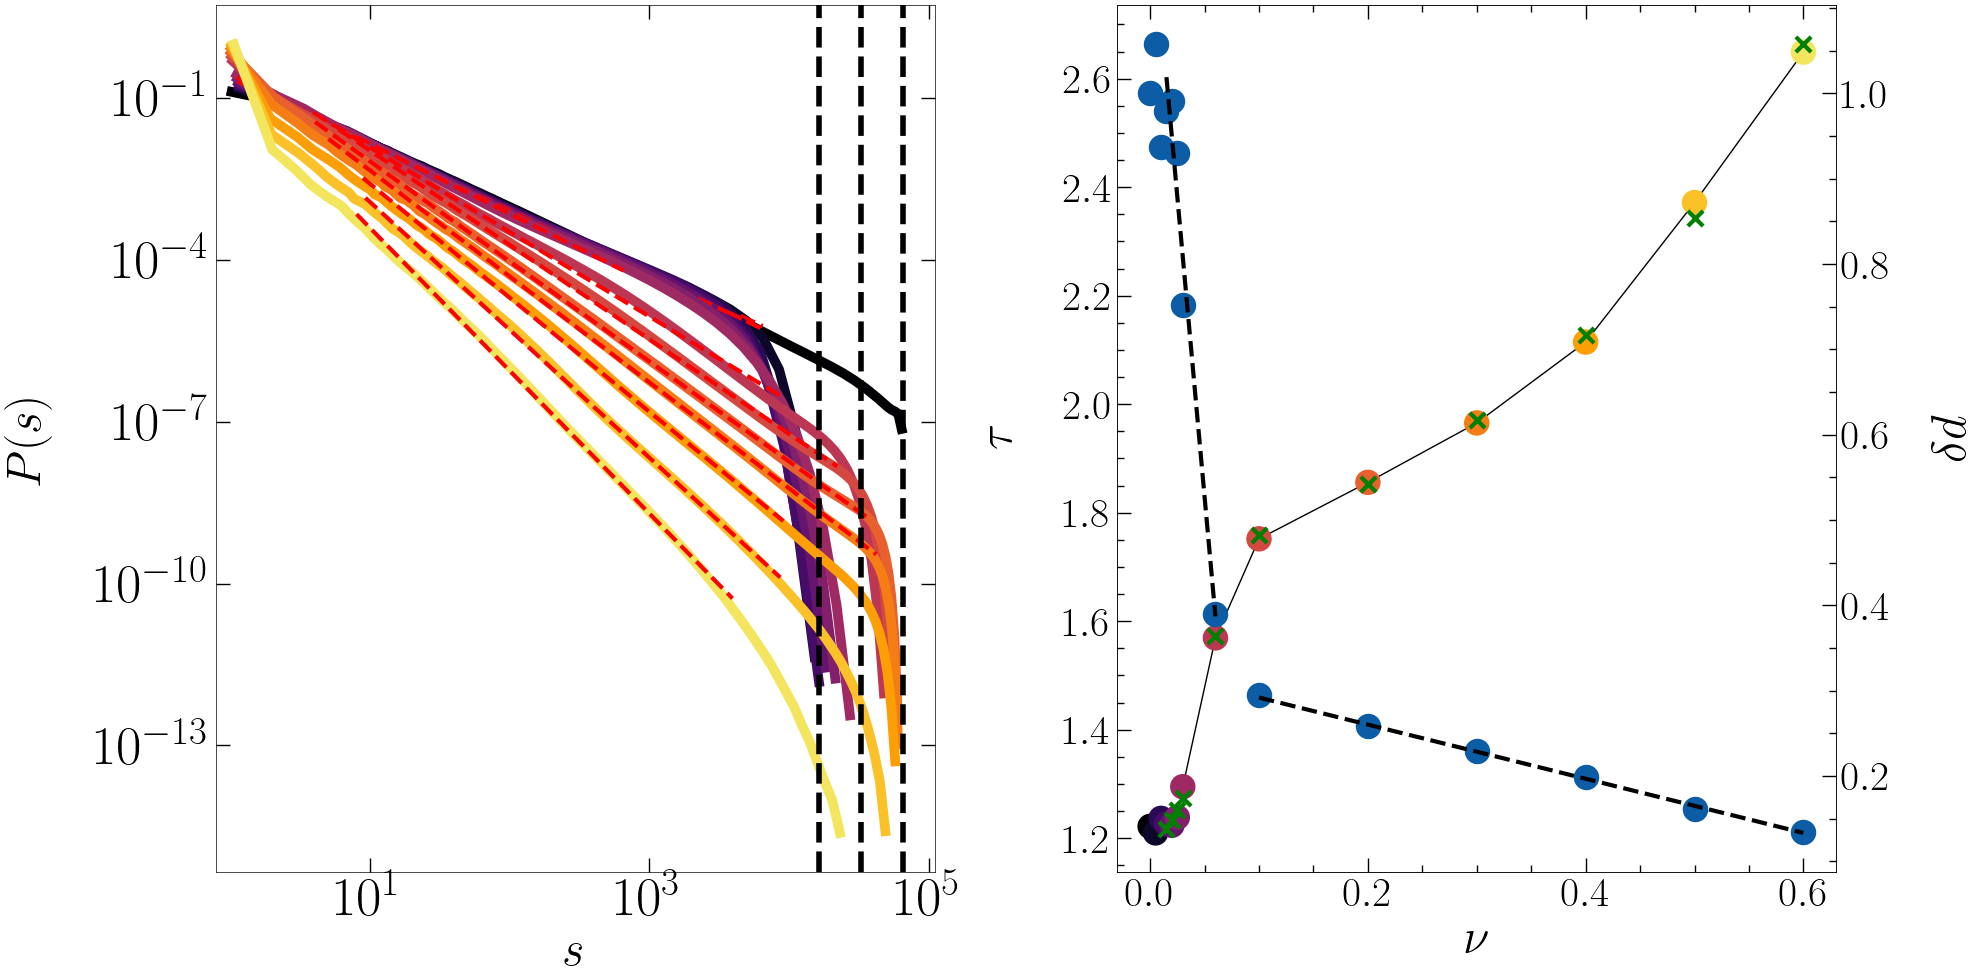

[-1.22180531 -1.20974943 -1.23656801 -1.22652052 -1.2238533  -1.23840558
 -1.29490603 -1.5691784  -1.75177144 -1.85594949 -1.96543565 -2.11448507
 -2.37162407 -2.64899891]


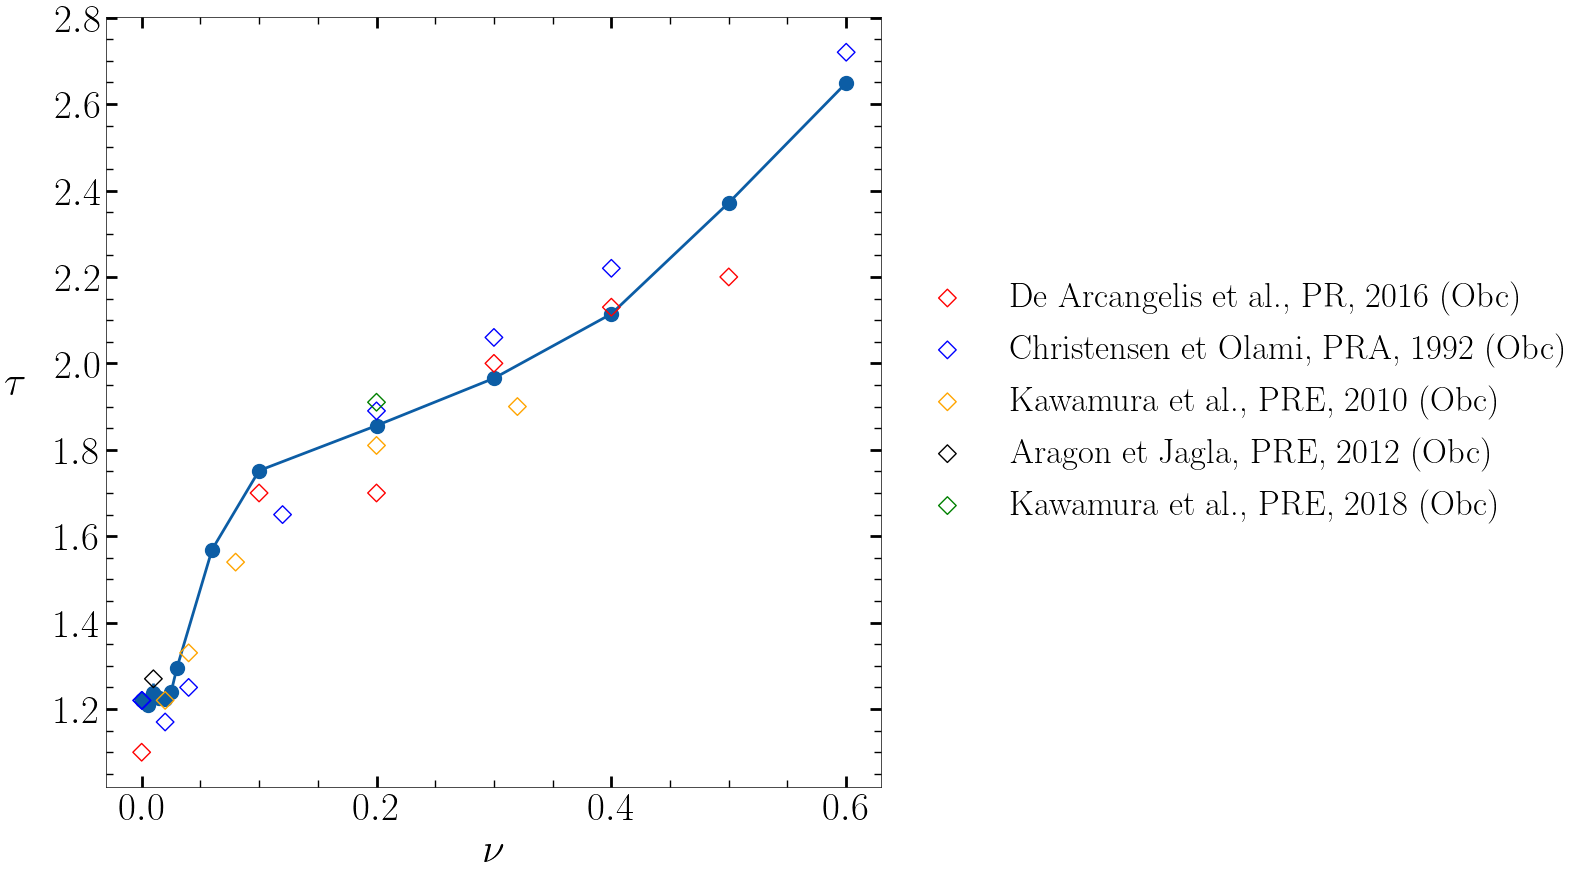

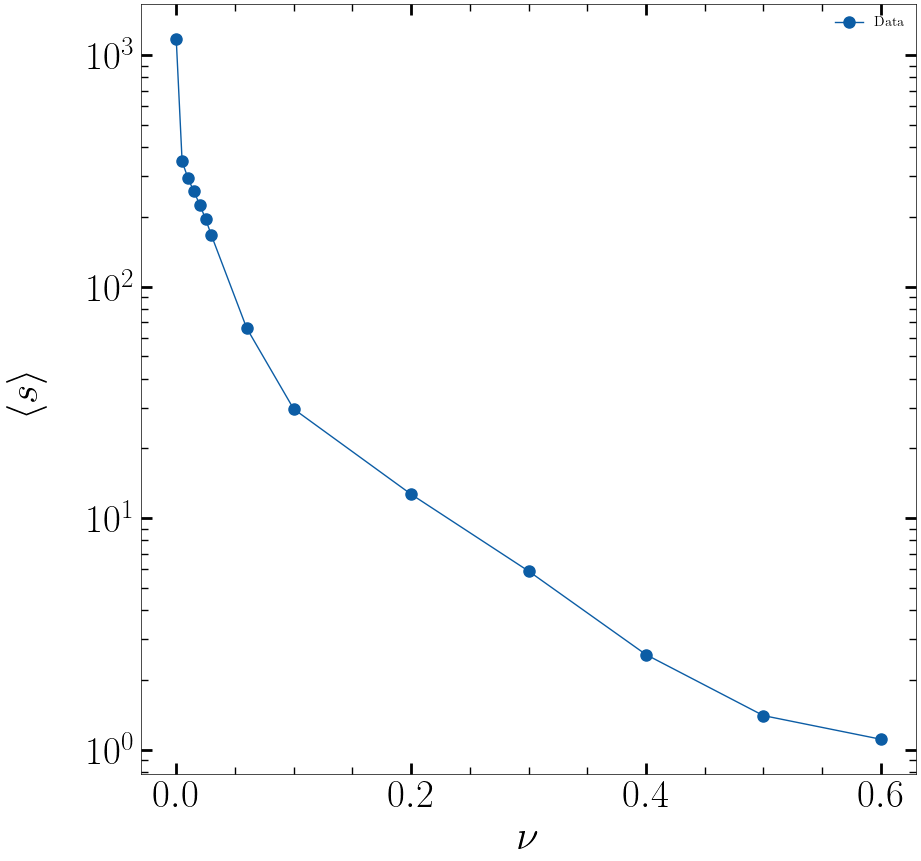

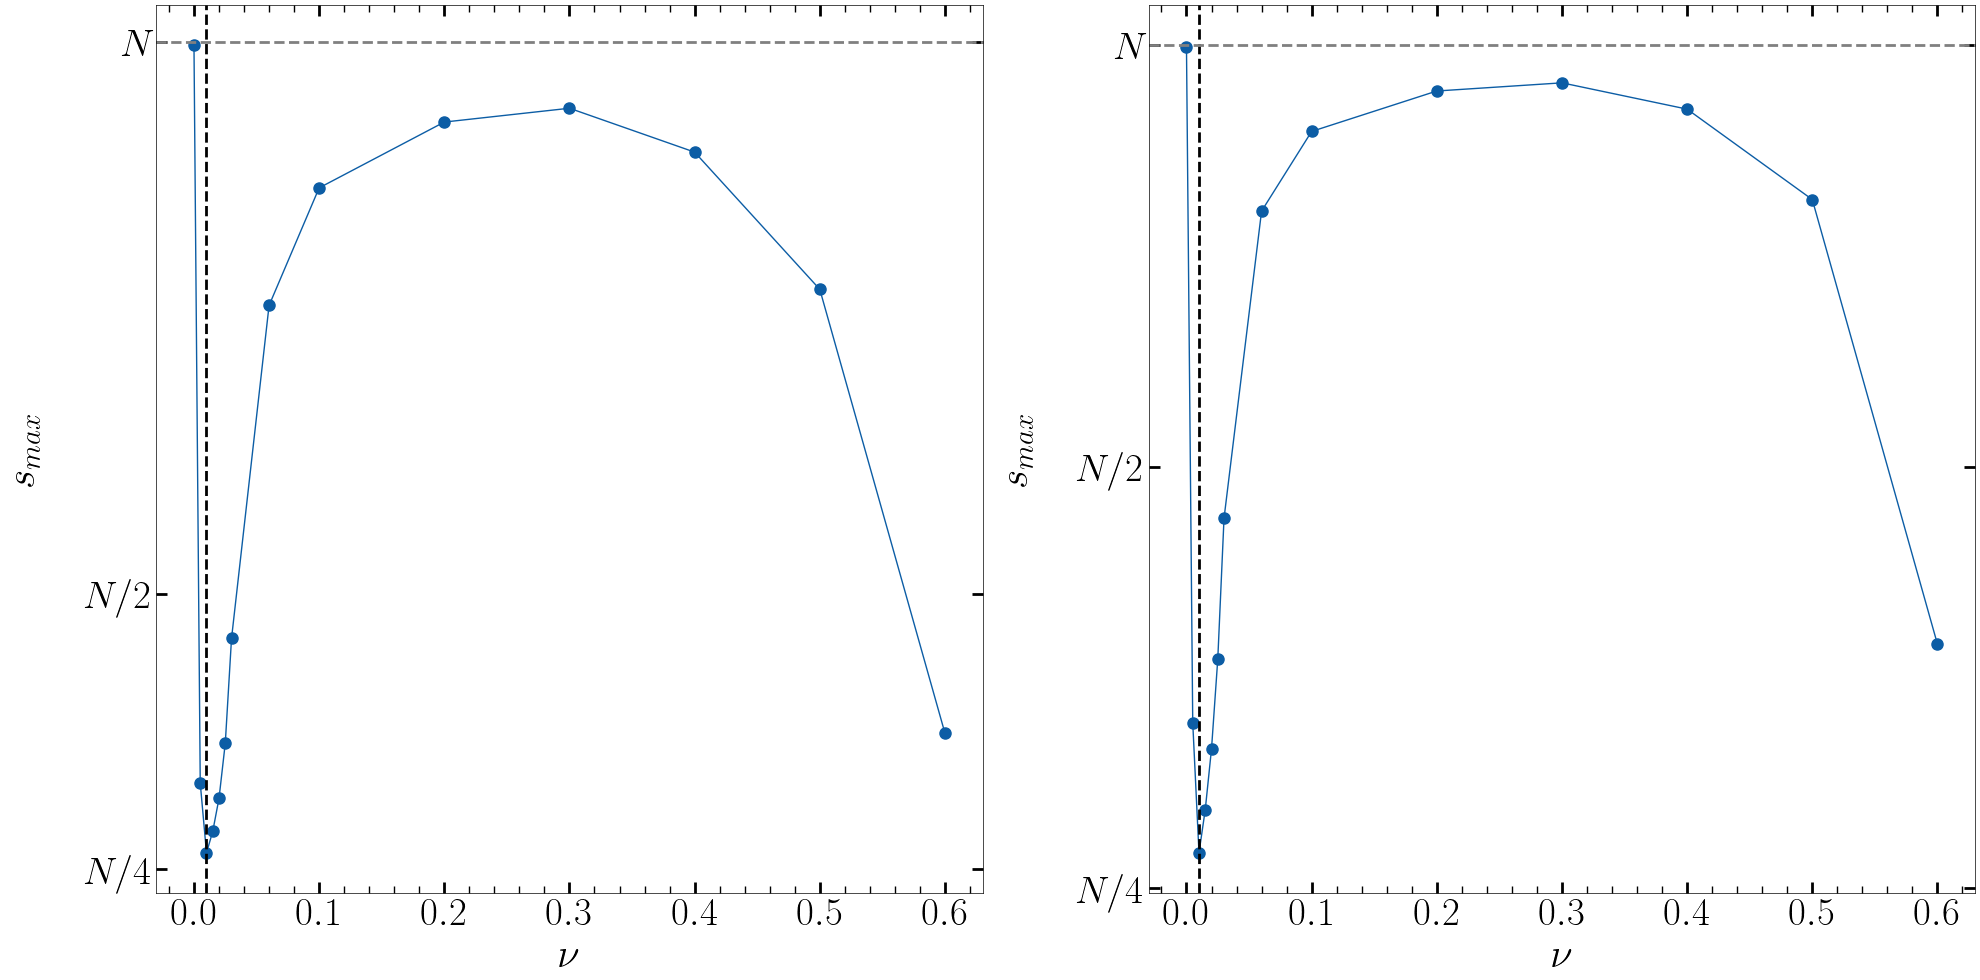

In [3]:
# Tstop_x = [4.e3, 1e-8, 7e-10,  1.1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-9, 5e-11, 1e-11]
# Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
Tstart_x = [2,4,4,4,1,0,1,3,5,4,4,8,8,8]
Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_fitting(Thisto_s, Tbins_s, Tstart_x, Tstop_x, Tvar)

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for i, (histo,bins, xfit, yfit, tau, nu) in enumerate(zip(Thisto_s,Tbins_s, Txfit_s, Tyfit_s, Ttau_s, Tvar)):
    ax1.plot(bins,histo, color = colors[i],linewidth=7)
    ax1.plot(xfit, yfit, 'r--', lw = 3)
    
print("err: ", Tperr_s)
ax2.plot(Tvar, -Ttau_s, linestyle = '-', c = 'k', zorder=1)
ax1.axvline(256 * 256, lw = 4, ls = '--', c = 'k')
ax1.axvline((256 * 256)/2, lw = 4, ls = '--', c = 'k')
ax1.axvline((256 * 256)/4, lw = 4, ls = '--', c = 'k')
ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
ax1.set_xlim(0.8,1.1e5)
# ax2.errorbar(Tvar, -Ttau_s, yerr = Tperr_s, color = 'k', zorder=2)
ax2.scatter(Tvar, -Ttau_s, color = colors[:], zorder=2, marker = 'o', s = 300, label = r'$\tau$')
       
#Calc la dimension fractal


Ttau_bis = np.array((-Ttau_s[0]-1)/(-Ttau_s -1), dtype = float)
mask1 = slice(3,8)
mask2 = slice(8, 15)

a, b = np.polyfit(Tvar[mask1], Ttau_bis[mask1],1)
y1 = a * np.array(Tvar[mask1]) + b
a2, b2 = np.polyfit(Tvar[9:], Ttau_bis[9:],1)
y2 = a2 * np.array(Tvar[mask2]) + b2
print(Ttau_bis)

ax22 = ax2.twinx()
ax22.scatter(Tvar, Ttau_bis, color = 'C0', zorder=2, marker = 'o', s = 300)
ax22.plot(Tvar[mask1], y1, ls = '--', lw = 3, c = 'k', label = r'$\delta d$')
ax22.plot(Tvar[mask2], y2, ls = '--', lw = 3, c = 'k')

print("a = {}, b = {}".format(np.round(a, 2),np.round(b, 2)))
print("a2 = {}, b2 = {}".format(np.round(a2, 2),np.round(b2, 2)))


tau_from_fractl1 = ((-Ttau_s[0] - 1)/ ((a*np.array(Tvar[mask1]) + b))) + 1
tau_from_fractl2 = ((-Ttau_s[0] - 1)/ ((a2*np.array(Tvar[mask2]) + b2))) + 1

ax2.scatter(Tvar[mask1], tau_from_fractl1, marker = 'x', s = 120, c = 'green', zorder = 10, lw = 3, label = r'$\tau_{fit}$')
ax2.scatter(Tvar[mask2], tau_from_fractl2, marker = 'x', s = 120, c = 'green', zorder = 10, lw = 3)

para_fig(ax1, r'$s$', r'$P(s)$', type = 'loglog', labelsize = 35, tickssize= 40, width_M = 1, length_M = 10)
para_fig(ax2, r'$\nu$', r'$\tau$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
para_fig(ax22, r'$\nu$', r'$\delta d$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
plt.tight_layout()
plt.show()

print(Ttau_s)
#######With the litterature #######
Arcangelis_nu = [0,0.1,  0.2, 0.3, 0.4, 0.5]
Arcangelis_slope = [1.1, 1.7 ,1.7, 2.0, 2.13, 2.20]

Chris_Olami_nu = [0, 4e-4, 0.02, 0.04, 0.12, 0.2, 0.3, 0.4, 0.6]
Chris_Olami_slope = [1.22, 1.22, 1.17, 1.25, 1.65, 1.89, 2.06, 2.22, 2.72]

Kawamura_nu = [0.02, 0.04, 0.08, 0.2, 0.32]
Kawamura_slope = [1.22,1.33,1.54,1.81,1.90]

Aragon_nu = [0.01] #OFC*, pente supposé constante
Aragon_slope = [1.27]  

Wissel_nu = [0.2]
Wissel_slope = [1.91]

plt.figure(figsize=(10,10))
plt.errorbar(Tvar, - Ttau_s, yerr = Tperr_s, fmt = '-o', lw =2, markersize = 10, zorder= -1)
plt.scatter(Arcangelis_nu, Arcangelis_slope, facecolors = 'none', color = 'r', marker = 'D',s = 80, lw = 1, label = 'De Arcangelis et al., PR, 2016 (Obc)')
plt.scatter(Chris_Olami_nu, Chris_Olami_slope, facecolors = 'none', color = 'b', marker = 'D',s = 80, lw = 1, label = 'Christensen et Olami, PRA, 1992 (Obc)')
plt.scatter(Kawamura_nu, Kawamura_slope, facecolors = 'none', color = 'orange', marker = 'D',s = 80, lw = 1, label = 'Kawamura et al., PRE, 2010 (Obc)')
plt.scatter(Aragon_nu, Aragon_slope, facecolors = 'none', color = 'k', marker = 'D',s = 80, lw = 1, label = 'Aragon et Jagla, PRE, 2012 (Obc)')
plt.scatter(Wissel_nu, Wissel_slope, facecolors = 'none', color = 'g', marker = 'D',s = 80, lw = 1, label = 'Kawamura et al., PRE, 2018 (Obc)')
plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.legend(title_fontsize = 23, ncol = 1, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.show()


####### MEAN SIZE ########
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(Tvar, Tmean_s, markersize = 8, marker = 'o', label = "Data")
# ax.plot(Tvar, Tana_mean, markersize = 8, marker = 'o', label = "Theory")
# ax.axvline(Tvar[4], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[4]))
para_fig(ax, r'$\nu$', r'$\langle s \rangle$', type = 'semilog')
plt.legend()

from matplotlib.ticker import FixedLocator, NullLocator
####### MAX SIZE ########
N = L1*L2

fig, ax = plt.subplots(1,2, figsize = (20,10))
ax[0].plot(Tvar, Tnonzero_s, markersize = 8, marker = 'o')
ax[0].axvline(Tvar[2], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
# ax[0].axhline(L1 * L2, c = "grey", lw = 2, ls = '--')
ax[0].axhline(N, c = "grey", lw = 2, ls = '--')

ax[1].plot(Tvar, Tnonzero_s, markersize = 8, marker = 'o')
ax[1].axvline(Tvar[2], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
# ax[1].axhline(L1 * L2, c = "grey", lw = 2, ls = '--')
ax[1].axhline(N, c = "grey", lw = 2, ls = '--')


para_fig(ax[0], r'$\nu$', r'$s_{max}$',)
para_fig(ax[1], r'$\nu$', r'$s_{max}$',type = 'semilog')


yticks = [N, N/2, N/4]
ax[0].yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
ax[0].yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
ax[0].set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])
ax[1].yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
ax[1].yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
ax[1].set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])

plt.tight_layout()
plt.show() 


###     We want to know the number of avalanche necessary in the case $\nu = 0.6$

In [5]:
lengthtab = L1 * L2
nbins = 100

data = np.loadtxt(f"/data1/DATA_Duplat/Brut/PDF/PD5n12/stat_histosize.txt", comments = "#") #load linear histogram
last_non_zero = np.nonzero(data)[0]

nbins = 100
log_bins = np.logspace(np.log10(1), np.log10(len(data)), nbins + 1)
log_histo = np.zeros(nbins)
lin_bins = np.arange(0, len(data))
# print(linbins)

norm_data = data/np.sum(data)
for i in range(len(log_bins) - 1): #Take the lin histo and turn it into a log histo
    # Trouver les bins linéaires qui chevauchent le bin logarithmique courant
    overlap = (lin_bins >= log_bins[i]) & (lin_bins < log_bins[i + 1])
    # Ajouter les comptages de ces bins linéaires au bin logarithmique
    if len(norm_data[overlap])!=0:
        log_histo[i] = np.sum(norm_data[overlap])/len(norm_data[overlap])

    
    
# Renorm the histogram
bin_widths = np.diff(log_bins)  # Largeur de chaque bin logarithmique
area = np.sum(log_histo * bin_widths)  # Calcul de l'aire sous la courbe
log_histo_normalized = log_histo / area  # Normalisation

mask2 = log_histo_normalized != 0
mask3 = log_histo != 0

log_y = np.log(log_histo_normalized[3:-3][log_histo_normalized[3:-3] !=0])
log_x = np.log(log_bins[3:-4][log_histo_normalized[3:-3] !=0])


coeffs = np.polyfit(log_x, log_y, 1)
a = np.exp(coeffs[1])
b = coeffs[0]

fit = a * log_bins[:-1][mask2]**b

y_smax = a * (L1 * L2)**b
y_smax_real = y_smax * area
print("Nb of avalanche needed: ",y_smax_real)


Nb of avalanche needed:  1.6179525897704826e-11


###     Zoom sur cas faible dissipation

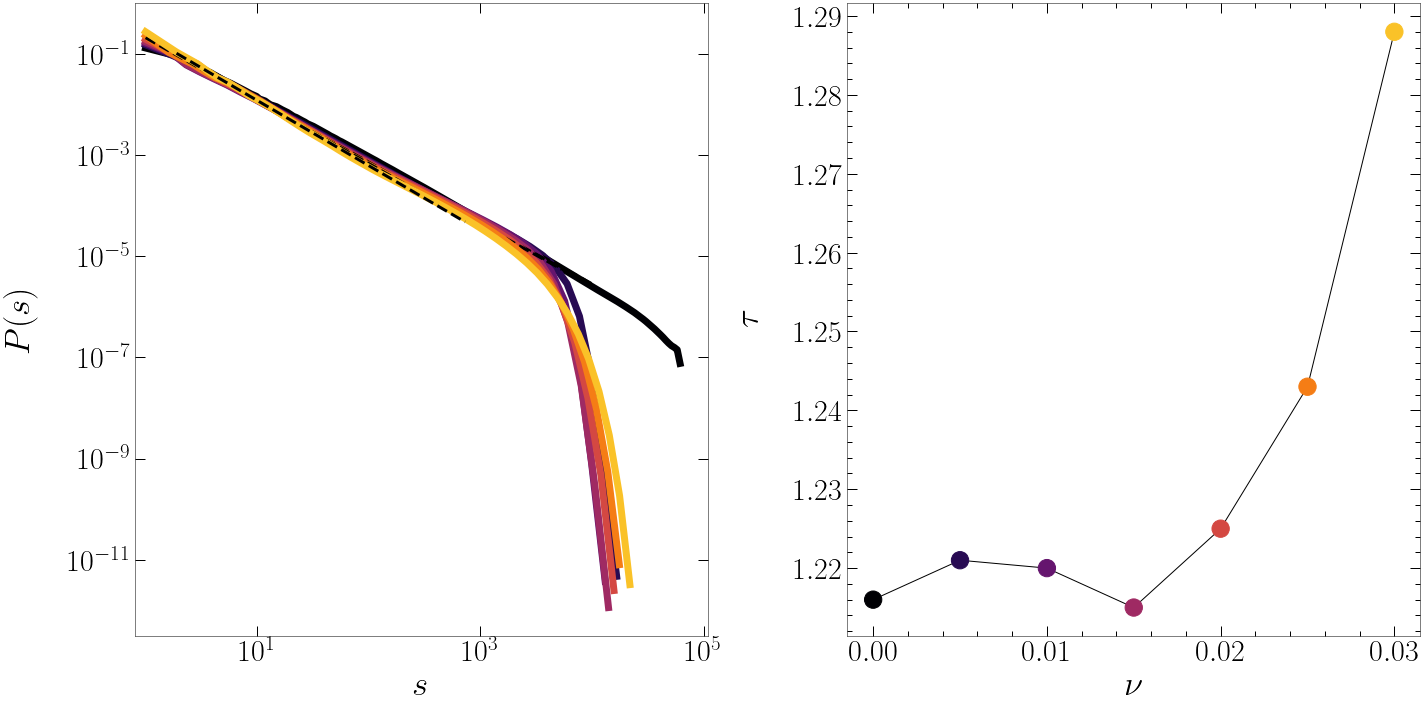

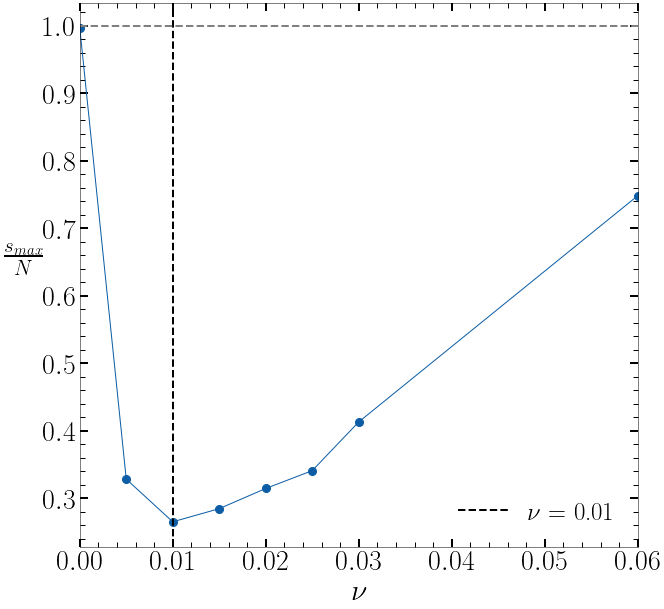

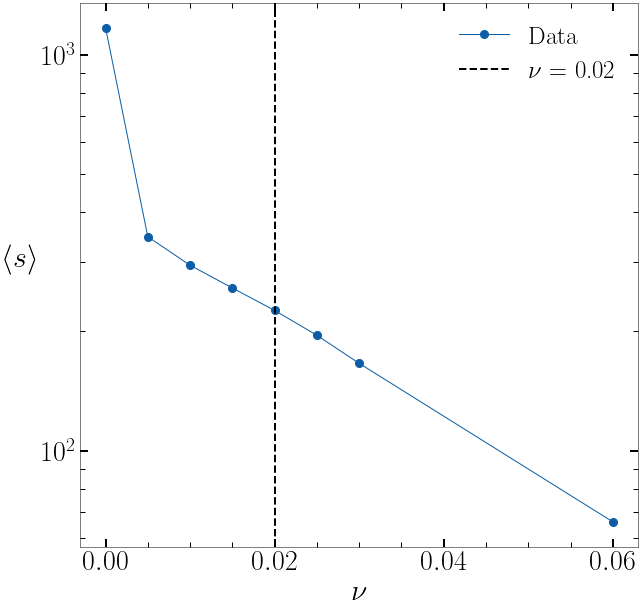

In [6]:

islice = slice(0,7)

NCURVES = len(Tvar[islice])
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for i, (histo, xfit, yfit, tau, nu) in enumerate(zip(Thisto_s[islice], Txfit_s[islice], Tyfit_s[islice], Ttau_s[islice], Tvar[islice])):
    ax1.plot(histo[:,0],histo[:,1], color = colors[i],linewidth=7, label = f"{nu}\nb = {-Tnstat_s[i]:.2f}")
    ax1.plot(xfit, yfit, 'k--', lw = 3)

ax2.plot(Tvar[islice], -Ttau_s[islice], linestyle = '-', c = 'k', zorder=1)

ax1.set_xticks([1e0, 1e1, 1e2, 1e3, 1e4, 1e5])
ax1.set_xlim(0.8,1.1e5)
ax2.scatter(Tvar[islice], -Ttau_s[islice], color = colors[:], zorder=2, marker = 'o', s = 300)
       

para_fig(ax1, r'$s$', r'$P(s)$', type = 'loglog', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
para_fig(ax2, r'$\nu$', r'$\tau$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
plt.tight_layout()
plt.show()

#######S_max#######
plt.figure(figsize = (10,10))
plt.plot(Tvar, Tnonzero_s/(L1 * L2), markersize = 8, marker = 'o')
plt.axvline(Tvar[2], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[2]))
plt.axhline(1, c = "grey", lw = 2, ls = '--')
plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$\frac{s_{max}}{N}$', fontsize = 30, rotation = 0,labelpad= 20)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.xlim(0,Tvar[7])
plt.legend(fontsize = 25)
plt.show()

#######S_mean#######


plt.figure(figsize = (10,10))
ax2 = plt.subplot(1,1,1)

ax2.plot(Tvar[:8], Tmean_s[:8], markersize = 8, marker = 'o', label = "Data")
# ax2.plot(Tvar[:8], Tana_mean[:8], markersize = 8, marker = 'o', label = "Theory")
ax2.axvline(Tvar[4], lw = 2, ls = '--', c = 'k', label = "{} = {}".format(macros['diss'], Tvar[4]))
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\langle s \rangle$', fontsize = 30, rotation = 0,labelpad= 20)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale("log")

plt.legend(fontsize = 25)
plt.show()

### Cumulative distribution function


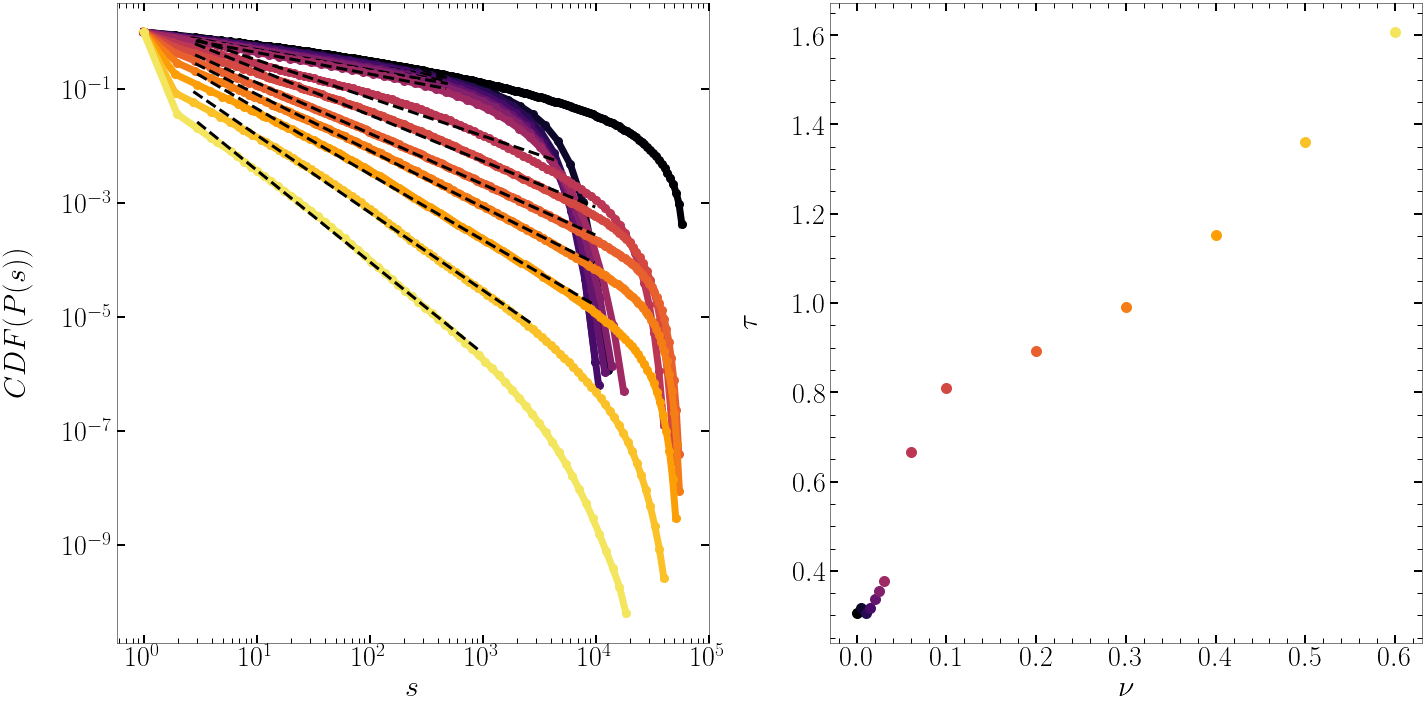

In [7]:
from scipy.integrate import cumtrapz

Tstart_x = [2,2,2,2,2,
            2,2,2,2,2,
            2,2,2,2]

Tstop_x = [5e2,5e2,5e2,5e2,5e2,
           5e2,5e2,5e3,1e4,1e4,
           1e4,1e4,3e3,1e3]

Tcdf = [cumtrapz(histo[:,1], histo[:,0], initial=0) for histo in Thisto_s]
Tcdf = [cdf/cdf[-1] for cdf in Tcdf]

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

fig, (ax1, ax2) = plt.subplots(1,2,figsize = (20, 10))
for j, (bins_histo, cdf, start_x, stop_x) in enumerate(zip(Thisto_s, Tcdf, Tstart_x, Tstop_x)):
    
    inv_cdf = 1 - cdf
    bins = bins_histo[:,0]
    filtered_inv_cdf = inv_cdf[inv_cdf!=0]
    filtered_bins = bins[inv_cdf!=0]
    
    result, xs, _ , perr = fit_powerlaw(filtered_bins, filtered_inv_cdf, stop_x = stop_x, start_x = start_x, switch = 1,  plot=True, f_scale=1.0,
                                        function_to_fit='power')
    
    ax1.plot(filtered_bins, filtered_inv_cdf, color = colors[j], lw = 7, marker = 'o', markersize = 8)
    ax1.plot(xs, powerlaw(xs, *result.x), color = 'k', ls = '--', lw = 3)
    ax2.scatter(Tvar[j], -result.x[1], color = colors[j], marker = 'o', s = 100)


para_fig(ax1, r'$s$', r'$CDF(P(s))$',type = 'loglog')
para_fig(ax2, r'$\nu$', r'$\tau$')
plt.tight_layout()
plt.show()


##      Topplings

In [2]:
""" lengthtab = L1 * L2 * 1000 """


# results_t = Parallel(n_jobs=-1)(delayed(process_top)(folder, lengthtab, nbins, nmin, nmax)
#                                   for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))

# Tndist_t, Tndatafit_t, Tnstat_t, Tnzero_t, Tmean_t = np.array(results_t).T
Thisto_t, Tbins_t, Tnonzero_t, Tmean_t,Tnbins_t = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histotop.txt".format(folder))
                                                                    for  folder in folderpath)).T

/tmp/ipykernel_2205578/1441808617.py:8: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_t, Tbins_t, Tnonzero_t, Tmean_t,Tnbins_t = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histotop.txt".format(folder))


0.971384667486899
0.9178435251723747
0.9613564346355827
0.9724444129583114
0.9918844882195549
0.9908988953236654
0.9821554743164974
0.956264064257372
0.877347421342413
0.9736011419895022
0.9175549339178355
0.9116262831850164
0.7140452851752981
0.9036870759140027


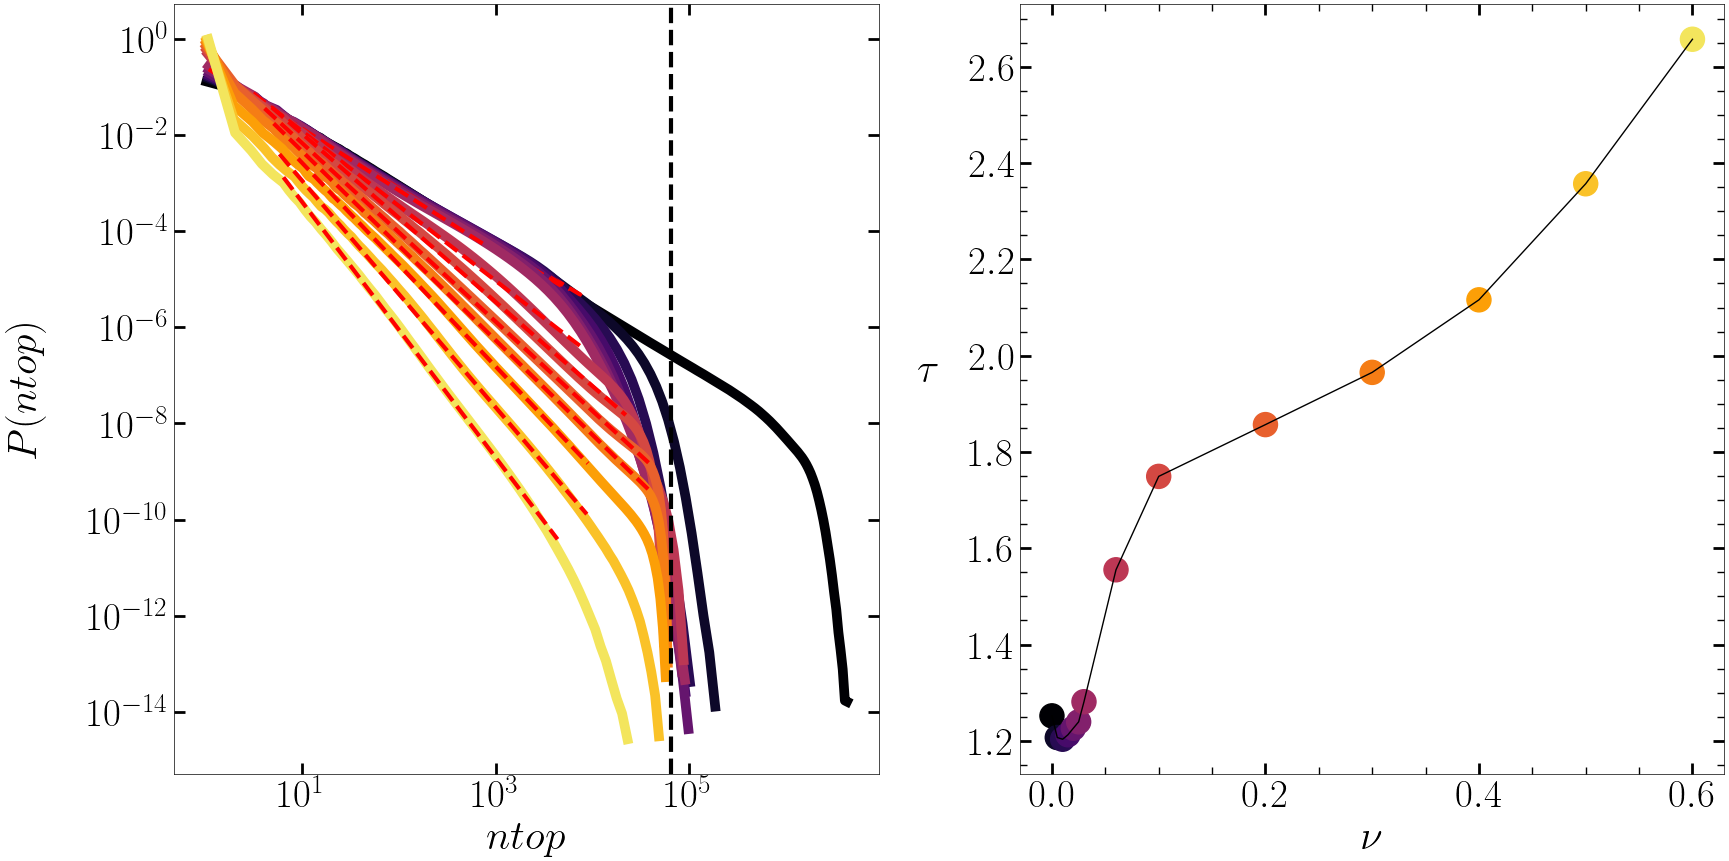

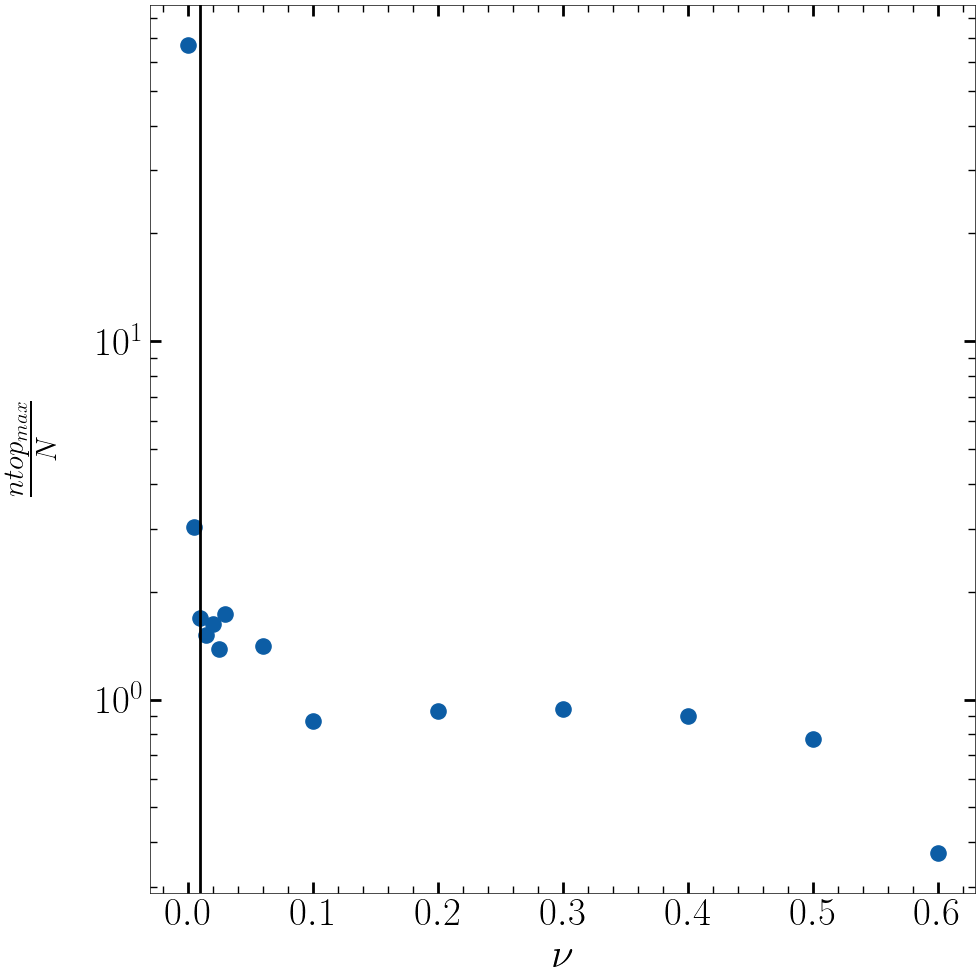

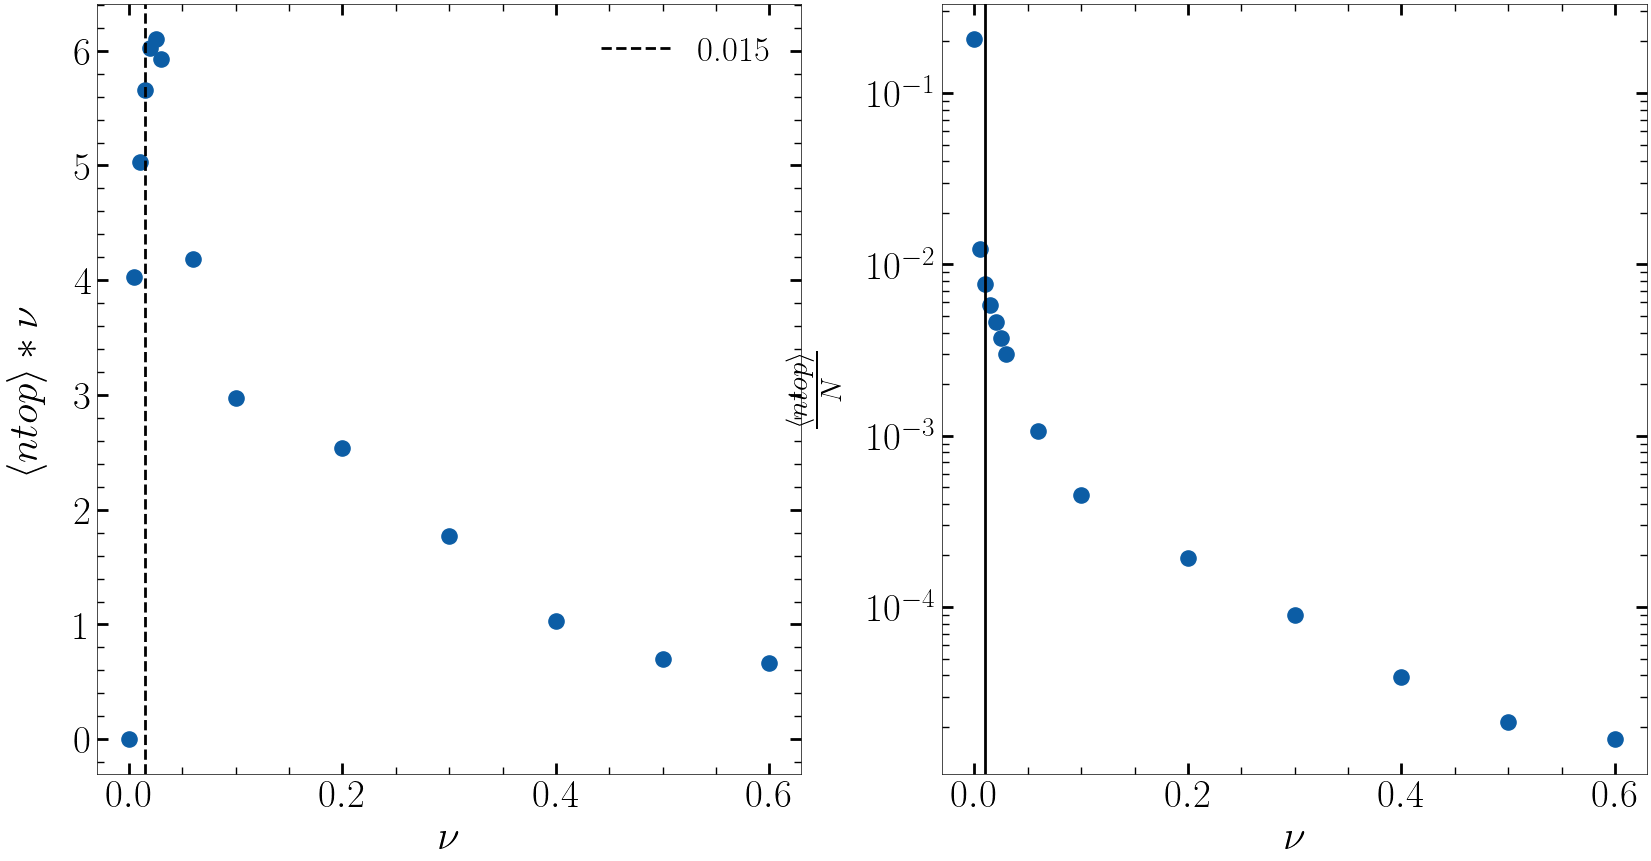

In [5]:
# Tstop = [1e5, 3e-4, 4e-4, 8.5e-5, 4e-5,
#         5e-5, 3e-5, 1e-7, 1e-8, 1e-9,
#         1e-10, 1e-11, 1e-11, 1e-12]
Tstop_x = [4.e3, 1.1e4, 9e3, 8e3, 6e3, 1e3, 1e3, 1e4, 2.5e4, 4e4, 4.6e4, 1e4, 1e4, 5e3, 3.8e3]
Tstart_x = [2,1,1,1,1,2,1,2,4,4,4,8,5,5]

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

# Thisto, Txfit, Tyfit, Ttau_t, Tperr_t = PDF_top_histogram(Tndist_t, Tstart_x, Tstop, Tvar)
Txfit_t, Tyfit_t, Ttau_t, Tperr = PDF_fitting(Thisto_t, Tbins_t, Tstart_x, Tstop_x, Tvar)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for histo, bins, xfit, yfit, tau_t, color in zip(Thisto_t, Tbins_t, Txfit_t, Tyfit_t, Ttau_t, colors):
    ax1.plot(bins, histo, color = color, lw = 7)
    ax1.plot(xfit, yfit, 'r--', lw = 3)


ax2.scatter(Tvar, -Ttau_t, color = colors[:], marker = 'o', s = 300)
ax2.plot(Tvar, -Ttau_t, linestyle = '-', c = 'k', zorder=1)

ax1.axvline(L1 * L2, c = 'k', lw = 3, ls ='--')
para_fig(ax1, r"$ntop$", r"$P(ntop)$", type = 'loglog')

# ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()


plt.figure(figsize = (10,10))
""" ax1 = plt.subplot(1,2,1) """
ax2 = plt.subplot(1,1,1)
""" ax3 = plt.subplot(1,3,3) """


# ax1.scatter(Tvar, Tnonzero_t/(L1 * L2), s = 120)
# para_fig(ax1, r'$\nu$', r'$\frac{ntop_{max}}{N}$')

ax2.scatter(Tvar, Tnonzero_t/(L1 * L2), s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
para_fig(ax2, r'$\nu$', r'$\frac{ntop_{max}}{N}$', type = 'semilog')

""" ax3.scatter(Tvar, Tnonzero_t/(L1 * L2), s = 120)
para_fig(ax3, r'$\nu$', r'$\frac{ntop_{max}}{N}$', type = 'loglog') """
plt.tight_layout()
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.scatter(Tvar, Tmean_t * Tvar, s = 120)
ax1.set_xlabel(r'$\nu$', fontsize=30)
ax1.axvline(Tvar[3], linestyle = '--', lw = 2, c = 'k', label = '{}'.format(Tvar[3]))
ax1.set_ylabel(r'$\langle ntop \rangle * \nu$', fontsize = 30,labelpad= 20)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.legend(fontsize = 25)

ax2.scatter(Tvar, Tmean_t/(L1 * L2), s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30) 
ax2.set_ylabel(r'$\frac{\langle ntop \rangle}{N}$', fontsize = 30,labelpad= 20)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale("log")
plt.show()

##  Size exponants and Topplings exponants comparison

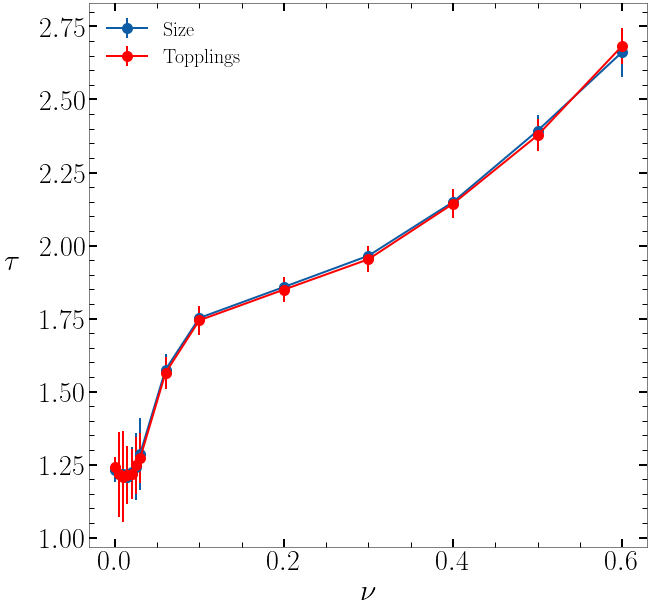

In [12]:
plt.figure(figsize = (10, 10))
plt.errorbar(Tvar, - Ttau_s, yerr = Tperr_s, fmt = '-o', lw = 2, markersize = 10, label = "Size", zorder = 3)
plt.errorbar(Tvar, -Ttau_t, yerr = Tperr_t, fmt = '-o', lw = 2, markersize = 10, c = 'r', label = "Topplings", zorder = 3)

plt.xlabel(r'$\nu$', fontsize=30)
plt.ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.legend(fontsize = 20)
plt.show()

##      Intertime

In [2]:
nbins = 1000

results_it = Parallel(n_jobs=-1)(delayed(process_time_from_histo)(folder, nbins + 1)
                                  for folder in folderpath)

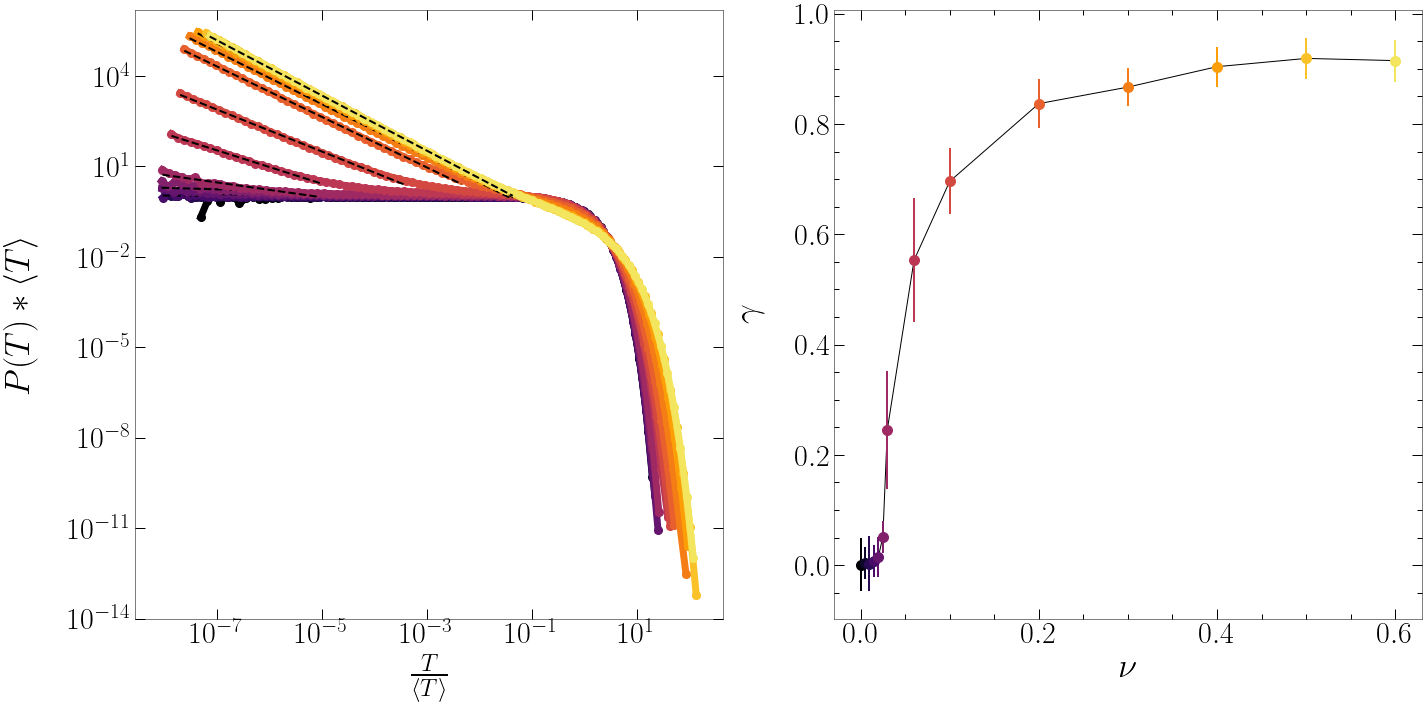

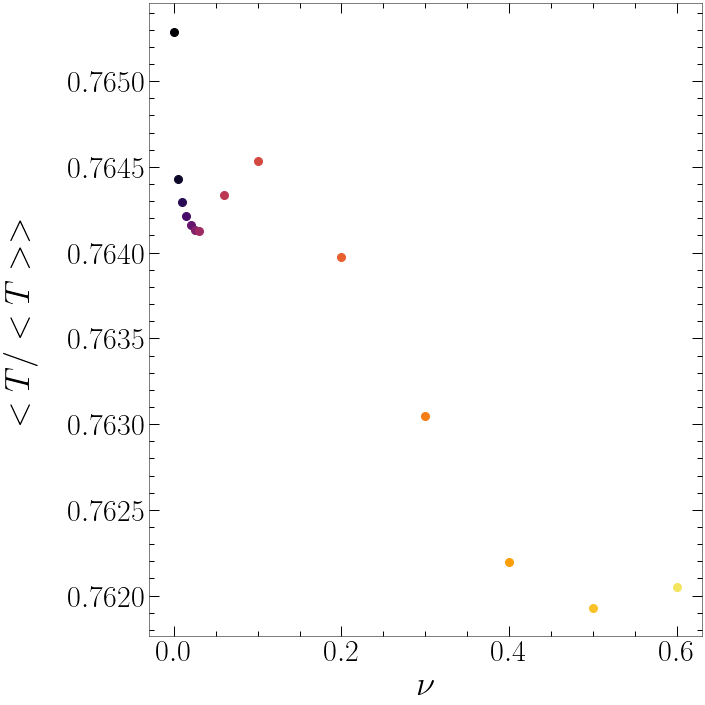

In [ ]:
Tstart_x = [1e-6,1e-10,1e-6,1e-10,1e-7,
           1e-10,1e-10,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tstop = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-5,1e-5,4e-4,5e-3,
        5e-2,5e-2,5e-2,5e-2]

nb_reduced_bins = 100

Thisto_it ,Txfit_it, Tyfit_it, Tgamma_it, Tperr_it =  PDF_it_histogram(np.array(results_it), Tstart_x, Tstop, nb_reduced_bins)

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20, 10))
for j, (histo, xfit, yfit) in enumerate(zip(Thisto_it, Txfit_it, Tyfit_it)):
    ax1.plot(histo[:,0], histo[:, 1], color = colors[j], lw = 7, marker = 'o', markersize = 8)
    ax1.plot(xfit,yfit, 'k--', lw = 2)
    
# poisson = gamma_distribution(histo[:,0], 1, -0.0, 1.)
# ax1.plot(histo[:,0], poisson, linestyle = '--', color = 'red', lw = 3, marker = 'o', markersize = 8)
ax1.set_ylim(1e-14, 1.5e6)
    
ax2.plot(Tvar, -Tgamma_it, linestyle = '-', c = 'k', zorder=1)
# ax2.scatter(Tvar, -Tgamma, c = colors[:], zorder=2, marker = 'o', s = 300)
for i in range(NCURVES):
    ax2.errorbar(Tvar[i], - Tgamma_it[i], yerr = Tperr_it[i], fmt = 'o', c = colors[i], lw =2, markersize = 10)


para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$P(T)*\langle T \rangle$', type = 'loglog', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
para_fig(ax2, r'$\nu$', r'$\gamma$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
plt.tight_layout()
plt.show()


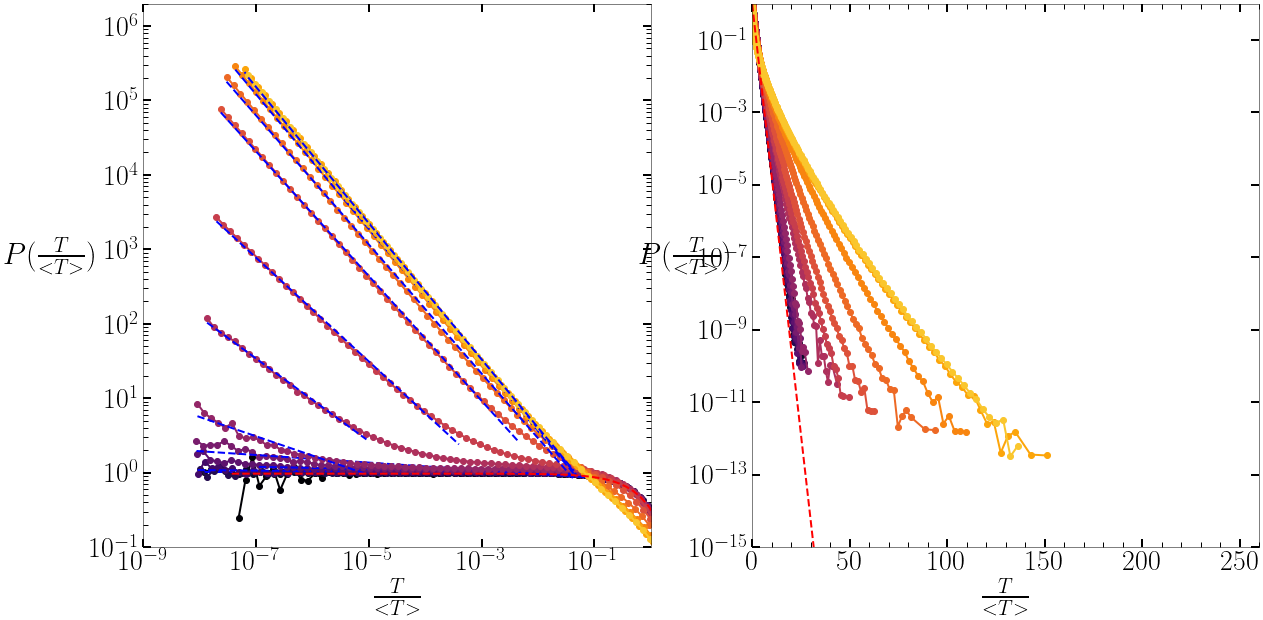

In [4]:

NCURVES = len(folderpath) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (bin_center, histo) in enumerate(results):
    
    bins_reduced, histo_reduced_norm = change_bins_log_histo(bin_center, histo, 100)
    
    mask = histo_reduced_norm!=0
    mask3 = histo!=0
    
    ax1.plot(bins_reduced[:-1][mask], histo_reduced_norm[mask], color = colors[j], marker = "o", lw = 2)
    ax2.plot(bin_center[mask3], histo[mask3], color = colors[j], marker = "o", lw = 2) # To have more bins
    
    result, xs, _ , perr = fit_powerlaw(bins_reduced[:-1][mask], histo_reduced_norm[mask], stop_x = Tstop[j], start_x = Tstart_x[j], f_scale=1.0,
                                function_to_fit='power', switch = 1)
            
    ax1.plot(xs, powerlaw(xs, *result.x), 'b--', lw = 2, label='$a={} \pm {}$'.format(np.round(result.x[1], 2),
                                                                        np.round(perr[1], 2)))

binsfit, histofit = results[0]
bins_reduced_fit, histo_reduced_norm_fit = change_bins_log_histo(binsfit, histofit, 100)

popt3, _ = curve_fit(expfct,bins_reduced_fit[:-1][histo_reduced_norm_fit!=0], histo_reduced_norm_fit[histo_reduced_norm_fit!=0])
a3,b3 = popt3
poisson = expfct(bins_reduced_fit[:-1], *popt3)
ax1.plot(bins_reduced_fit[:-1], poisson, linestyle = '--', color = 'r', lw = 2)
ax2.plot(bins_reduced_fit[:-1], poisson, linestyle = '--', color = 'r', lw = 2)


ax1.set_xlim(1e-9, 1)
ax1.set_ylim(1e-1, 2e6)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_yscale('log')
ax2.set_ylim(1e-15, 1)
ax2.set_xlim(0,260)
ax2.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax2.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

### Sans rescale

In [ ]:
def process_no_rescale(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    return bins, bin_centers, histo

results_no_rescale = Parallel(n_jobs=-1)(delayed(process_no_rescale)(folder, nbins + 1)
                                  for folder in folderpath)



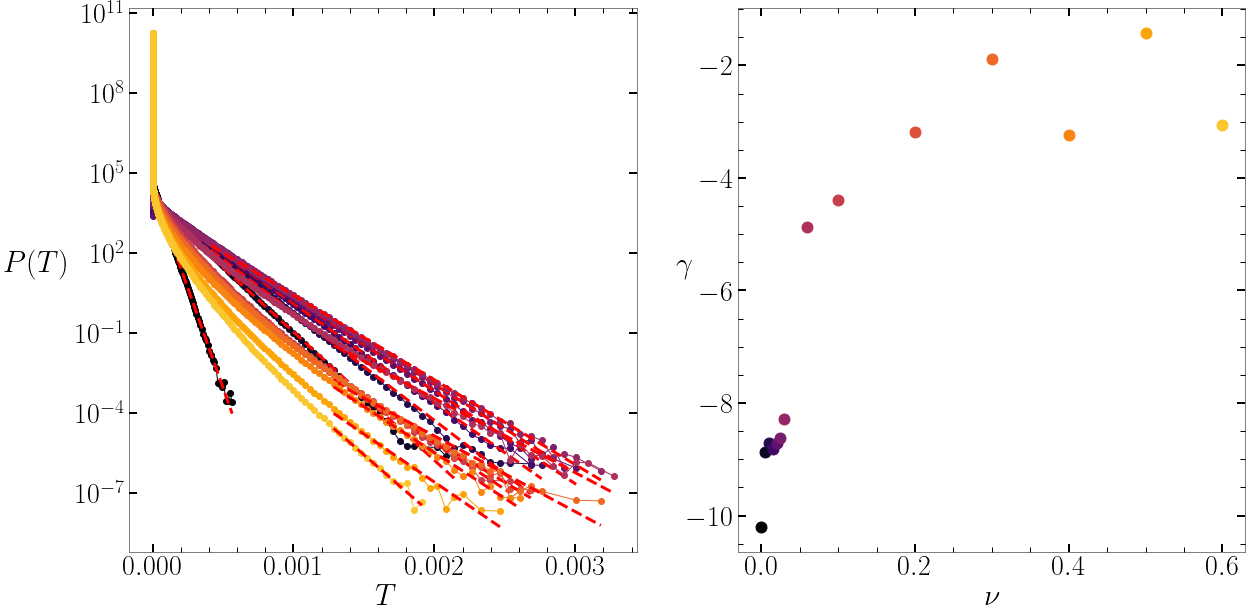

In [ ]:
Tnmin2 = np.array([650,700,700,700,700,700,700,  740,740,740,740,740,740,740])
Tnmax2 = np.array([790,900,900,900,900,790,790,  790,790,790,790,790,790,790]) 


NCURVES = len(folderpath) + 1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (bins, bin_center, histo) in enumerate(results_no_rescale):

    histo /= ((np.diff(bins)) * histo.sum())
    ax1.plot(bin_center[histo!=0], histo[histo!=0], color = colors[j], marker = "o")
    
    try:
        
        mask = histo[Tnmin2[j]:Tnmax2[j]]!=0
        a, b = np.polyfit(bin_center[Tnmin2[j]:Tnmax2[j]][mask], np.log(histo[Tnmin2[j]:Tnmax2[j]][mask]), 1)
        y_fit = np.exp(b) * np.exp(a * bin_center[Tnmin2[j]:Tnmax2[j]][mask])
        
        ax1.plot(bin_center[Tnmin2[j]:Tnmax2[j]][histo[Tnmin2[j]:Tnmax2[j]]!=0], y_fit, linestyle = "--", color = 'r', linewidth = 3)
        ax2.scatter(Tvar[j], -b, color  = colors[j], s = 120)
        
    except ValueError:
        print("Error")
        continue

ax1.set_yscale('log')

ax1.set_xlabel(r'$T$', fontsize = 30)
ax1.set_ylabel(r'$P(T)$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$\nu$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

### Size scaling

####     S = 2

In [8]:
nbins = 1000

results2 = Parallel(n_jobs=-1)(delayed(process_time_from_histo)(folder, nbins + 1, switch = 2)
                                  for folder in folderpath)



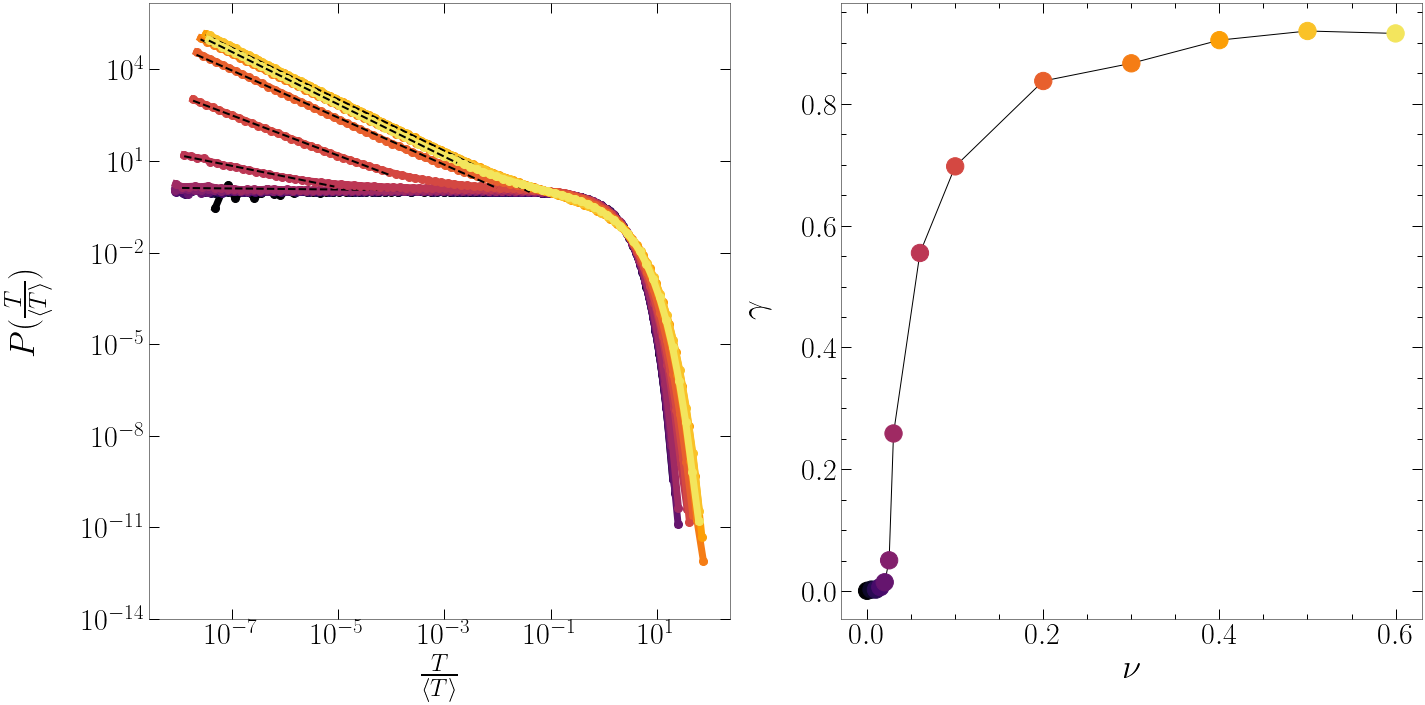

In [9]:
Tstart_x = [2e-6,1e-6,1e-6,1e-6,1e-6,
           2e-6,1e-8,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tstop = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-1,1e-5,1e-4,1e-2,
        5e-3,5e-3,5e-2,2e-3]

nb_reduced_bins = 100

Thisto2 ,Txfit2 , Tyfit2, Tgamma2, Tperr2 =  PDF_it_histogram(np.array(results2), Tstart_x, Tstop, nb_reduced_bins)

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20, 10))
for j, (histo, xfit, yfit) in enumerate(zip(Thisto2, Txfit2, Tyfit2)):
    
    ax1.plot(histo[:,0], histo[:, 1], color = colors[j], lw = 7, marker = 'o',markersize = 8)
    ax1.plot(xfit,yfit, 'k--', lw = 2)
    
# poisson = gamma_distribution(histo[:,0], 1, -0.0, 1.)
# ax1.plot(histo[:,0], poisson, linestyle = '--', color = 'red', lw = 3, marker = 'o', markersize = 8)
ax1.set_ylim(1e-14, 1.5e6)
    
ax2.plot(Tvar, -Tgamma, linestyle = '-', c = 'k', zorder=1)
ax2.scatter(Tvar, -Tgamma, c = colors[:], zorder=2, marker = 'o', s = 300)


para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
para_fig(ax2, r'$\nu$', r'$\gamma$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)

plt.tight_layout()
plt.show()

####    S = 10

In [10]:
var = 'nu'

minsize = 10
limdata = 1e8
nbins = 100

i = slice(3, -1)
results10 = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins, minsize, limdata) for folder in folderpath[i])
results10 = np.array(results10)

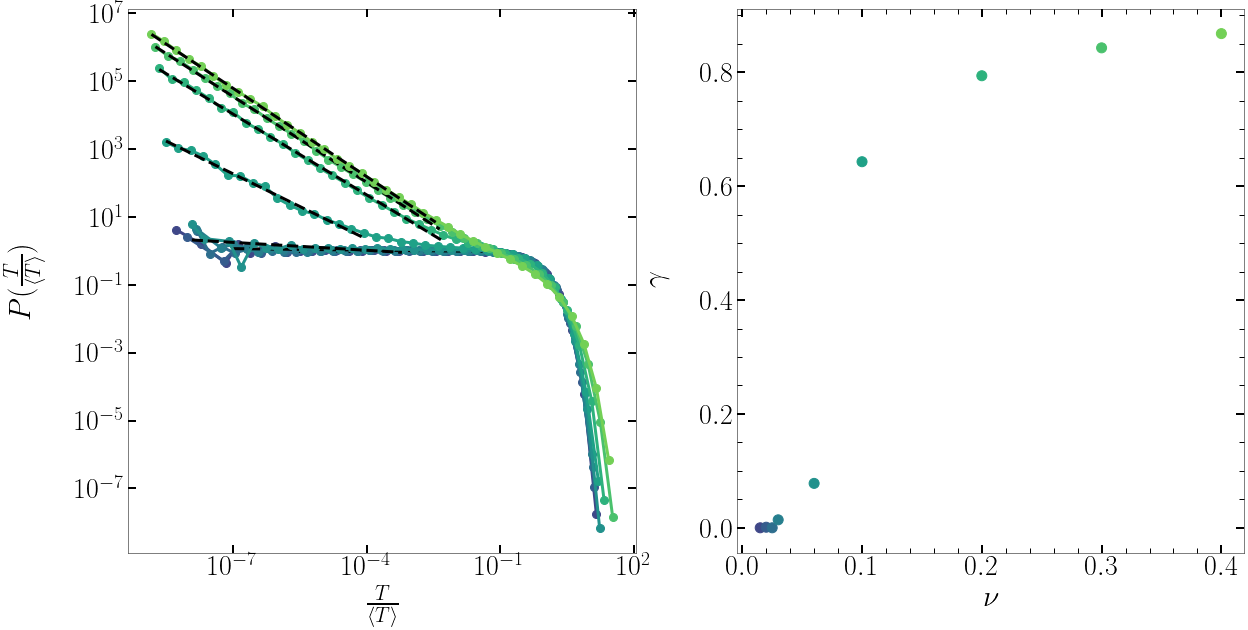

In [11]:
Tstart_x = [2e-6,1e-6,1e-6,1e-6,1e-6,
           2e-6,1e-7,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tstop = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-1,1e-3,1e-4,1e-2,
        5e-3,5e-3,5e-2,3e-2]


nb_reduced_bins = 50
Thisto10, Txfit10, Tyfit10, Tgamma10, Tperr10 = PDF_it_histogram(results10[:,[1,0],:], Tstart_x[i], Tstop[i], nb_reduced_bins)


a = 3
b = 12
c = a-3
d = c+(b-a)
k = slice(a, b)
j = slice(c, d)

NCURVES = len(folderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

fig, [ax1,ax2] = plt.subplots(1,2,figsize = (20,10))

for histo, xfit, yfit, color in zip(Thisto10[j], Txfit10[j], Tyfit10[j], colors[k]):
    ax1.plot(histo[:, 0], histo[:, 1], color = color, lw = 3,  marker = 'o', markersize = 8)
    ax1.plot(xfit, yfit, color = 'k', ls = '--', lw = 3)

ax2.scatter(Tvar[k], -Tgamma10[j], s = 100, c = colors[k])
para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog')
para_fig(ax2, r'$\nu$', r'$\gamma$')

####    S = 100

In [12]:
var = 'nu'

minsize = 100
limdata = 1e8
nbins = 100

i = slice(3, -1)
results100 = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins, minsize, limdata) for folder in folderpath[i])
results100 = np.array(results100)

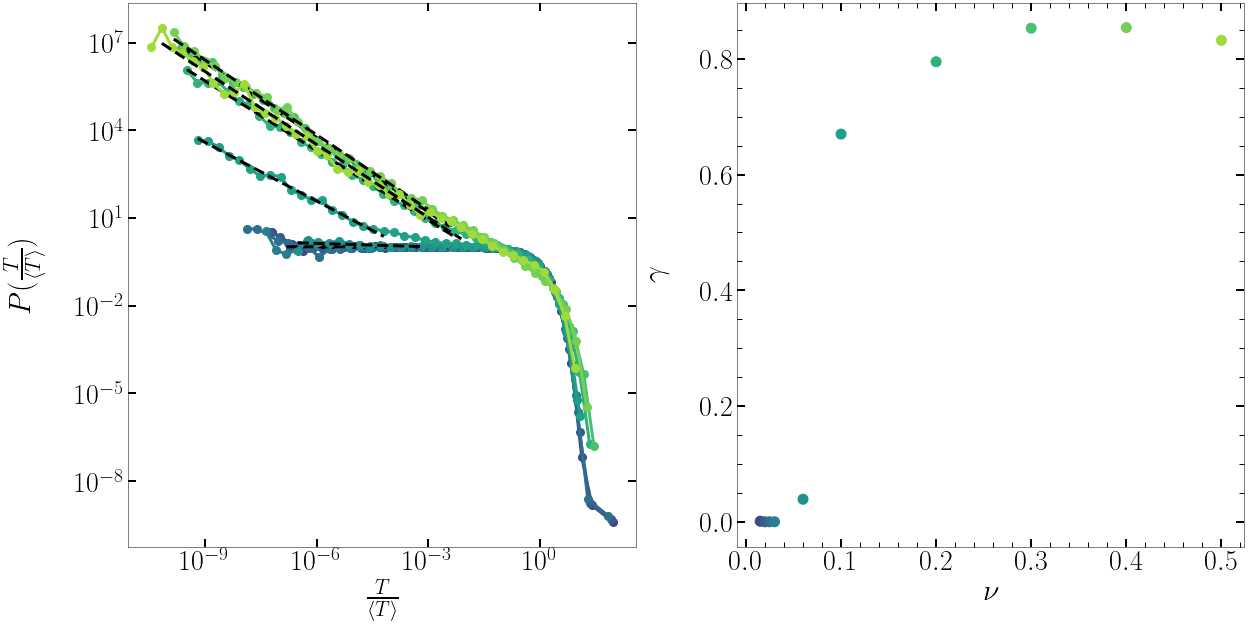

In [13]:
Tstart_x = [2e-6,1e-6,1e-6,1e-6,1e-6,
           2e-6,1e-7,1e-10,1e-10,1e-10,
           1e-10,1e-10,5e-11,1e-11]

Tstop = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-1,1e-3,1e-4,1e-2,
        5e-3,5e-3,1e-2,1e-2]


nb_reduced_bins = 50
Thisto100, Txfit100, Tyfit100, Tgamma100, Tperr100 = PDF_it_histogram(results100[:,[1,0],:], Tstart_x[i], Tstop[i], nb_reduced_bins)


a = 3
b = 13
c = a-3
d = c+(b-a)
k = slice(a, b)
j = slice(c, d)

NCURVES = len(folderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

fig, [ax1,ax2] = plt.subplots(1,2,figsize = (20,10))

for histo, xfit, yfit, color in zip(Thisto100[j], Txfit100[j], Tyfit100[j], colors[k]):
    ax1.plot(histo[:, 0], histo[:, 1], color = color, lw = 3,  marker = 'o', markersize = 8)
    ax1.plot(xfit, yfit, color = 'k', ls = '--', lw = 3)

ax2.scatter(Tvar[k], -Tgamma100[j], s = 100, c = colors[k])
para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog')
para_fig(ax2, r'$\nu$', r'$\gamma$')

####    S = 1000

In [14]:
var = 'nu'

minsize = 1000
limdata = 1e8
nbins = 100

i = slice(3, -1)
results1000 = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins, minsize, limdata) for folder in folderpath[i])
results1000 = np.array(results1000)

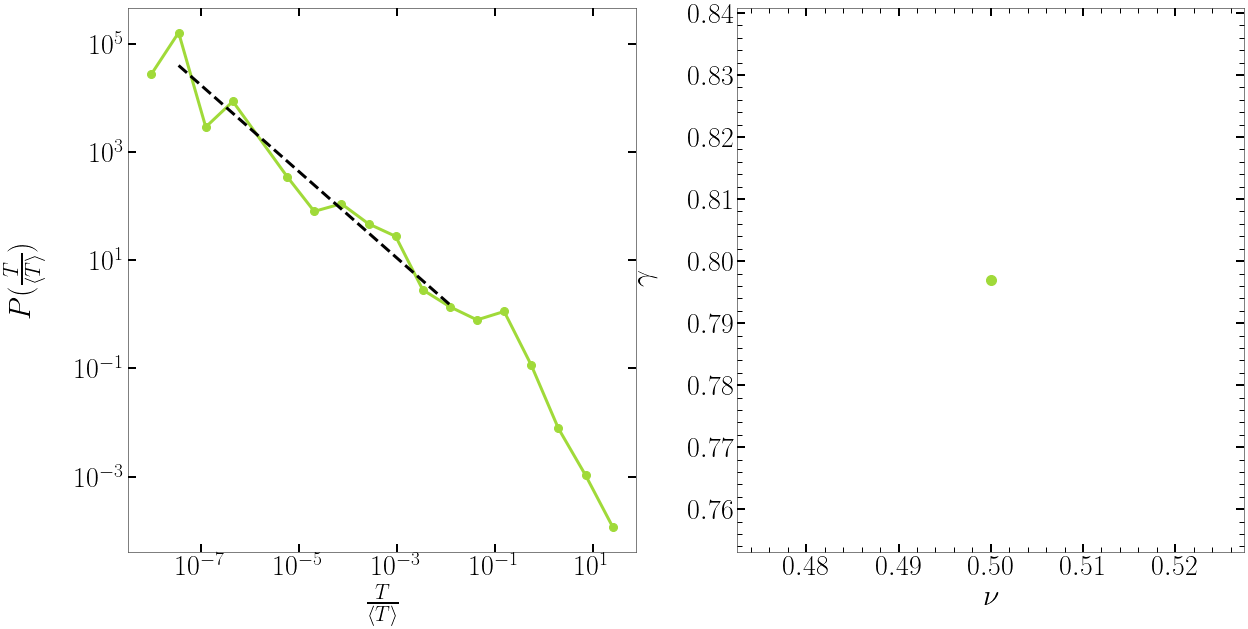

In [15]:
Tstart_x = [2e-6,1e-6,1e-6,1e-6,1e-6,
           2e-6,1e-7,2e-7,1e-10,1e-10,
           1e-12,1e-10,1e-8,   1e-10]

Tstop = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,5e-2,1e-3,1e-4,1e-3,
        1e-3,4e-4,2e-2,    1e-5]


nb_reduced_bins = 25
Thisto1000, Txfit1000, Tyfit1000, Tgamma1000, Tperr1000 = PDF_it_histogram(results1000[:,[1,0],:], Tstart_x[i], Tstop[i], nb_reduced_bins)


a = 12
b = 13
c = a-3
d = c+(b-a)
k = slice(a, b)
j = slice(c, d)

NCURVES = len(folderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

fig, [ax1,ax2] = plt.subplots(1,2,figsize = (20,10))

for histo, xfit, yfit, color in zip(Thisto1000[j], Txfit1000[j], Tyfit1000[j], colors[k]):
    ax1.plot(histo[:, 0], histo[:, 1], color = color, lw = 3,  marker = 'o', markersize = 8)
    ax1.plot(xfit, yfit, color = 'k', ls = '--', lw = 3)

ax2.scatter(Tvar[k], -Tgamma1000[j], s = 100, c = colors[k])
para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog')
para_fig(ax2, r'$\nu$', r'$\gamma$')

####    S = 6500

In [16]:
var = 'nu'

minsize = 6500
limdata = 1e7
nbins = 100

i = slice(3, -1)
results6500 = Parallel(n_jobs=-1)(delayed(process_time)(folder, nbins, minsize, limdata) for folder in folderpath[i])
results6500 = np.array(results6500)

In [17]:
Tstart_x = [2e-6,1e-6,1e-6,1e-6,1e-6,
           2e-6,1e-7,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tstop = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-1,1e-3,1e-4,1e-2,
        5e-3,5e-3,5e-2,3e-2]


nb_reduced_bins = 50
Thisto6500, Txfit6500, Tyfit6500, Tgamma6500, Tperr6500 = PDF_it_histogram(results6500[:,[1,0],:], Tstart_x[i], Tstop[i], nb_reduced_bins)


a = 3
b = 12
c = a-3
d = c+(b-a)
k = slice(a, b)
j = slice(c, d)

NCURVES = len(folderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

fig, [ax1,ax2] = plt.subplots(1,2,figsize = (20,10))

for histo, xfit, yfit, color in zip(Thisto6500[j], Txfit6500[j], Tyfit6500[j], colors[k]):
    ax1.plot(histo[:, 0], histo[:, 1], color = color, lw = 3,  marker = 'o', markersize = 8)
    ax1.plot(xfit, yfit, color = 'k', ls = '--', lw = 3)

ax2.scatter(Tvar[k], -Tgamma2[j], s = 100, c = colors[k])
para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog')
para_fig(ax2, r'$\nu$', r'$\gamma$')

IndexError: index 0 is out of bounds for axis 0 with size 0

####     Recap

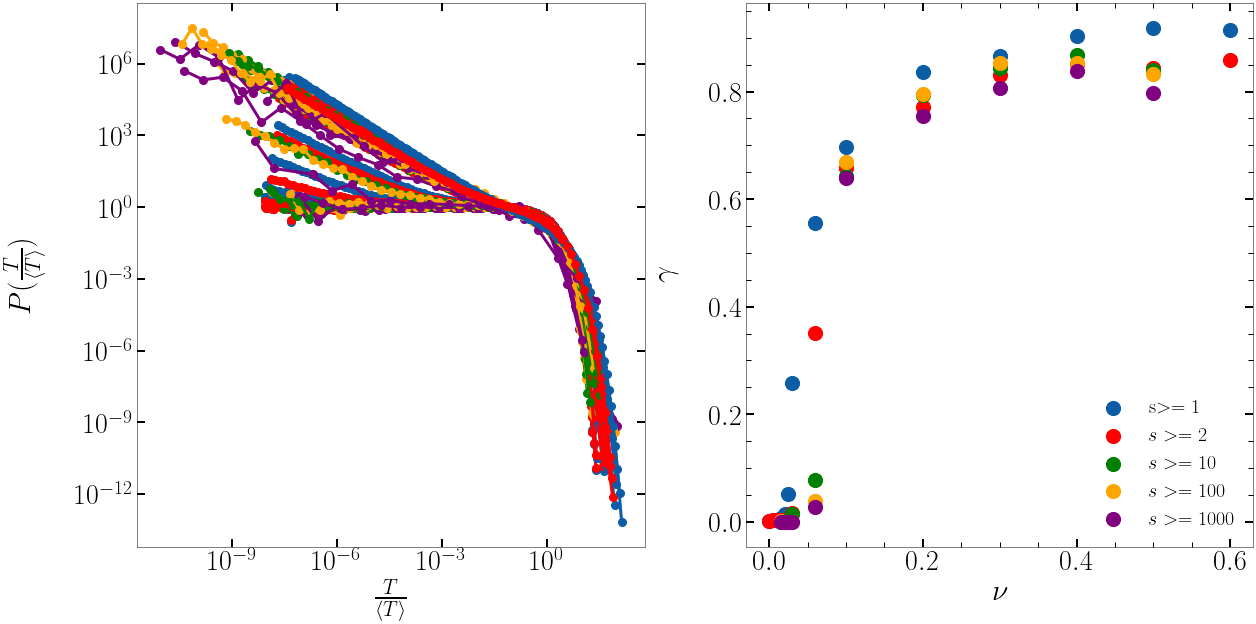

In [18]:
plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for i in range(len(folderpath)):
    
    ax1.plot(Thisto[i][ :, 0], Thisto[i][ :, 1], color = 'C0', linewidth = 3, marker = 'o', markersize = 8)
    ax1.plot(Thisto2[i][ :, 0], Thisto2[i][ :, 1], color = 'red', linewidth = 3, marker = 'o', markersize = 8)
    
    if (i >=3) and (i < 13):
        ax1.plot(Thisto10[i-3][ :, 0], Thisto10[i-3][ :, 1], color = 'green', linewidth = 3, marker = 'o', markersize = 8)
        ax1.plot(Thisto100[i-3][ :, 0], Thisto100[i-3][ :, 1], color = 'orange', linewidth = 3, marker = 'o', markersize = 8)
        ax1.plot(Thisto1000[i-3][ :, 0], Thisto1000[i-3][ :, 1], color = 'purple', linewidth = 3, marker = 'o', markersize = 8)
        
        
a = 3
b = 13
c = a-3
d = c+(b-a)
k = slice(a, b)


ax2.scatter(Tvar, -Tgamma, c = 'C0', zorder=2, marker = 'o', s = 200, label = r's$ >= 1$')
ax2.scatter(Tvar, -Tgamma2, c = 'red', zorder=2, marker = 'o', s = 200, label = r'$s >= 2$')
ax2.scatter(Tvar[k], -Tgamma10, c = 'green', zorder=2, marker = 'o', s = 200, label = r'$s >= 10$')
ax2.scatter(Tvar[k], -Tgamma100, c = 'orange', zorder=2, marker = 'o', s = 200, label = r'$s >= 100$')
ax2.scatter(Tvar[k], -Tgamma1000, c = 'purple', zorder=2, marker = 'o', s = 200, label = r'$s >= 1000$')

    
para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog')
para_fig(ax2, r'$\nu$', r'$\gamma$')
ax2.legend(fontsize = 20)

plt.show()

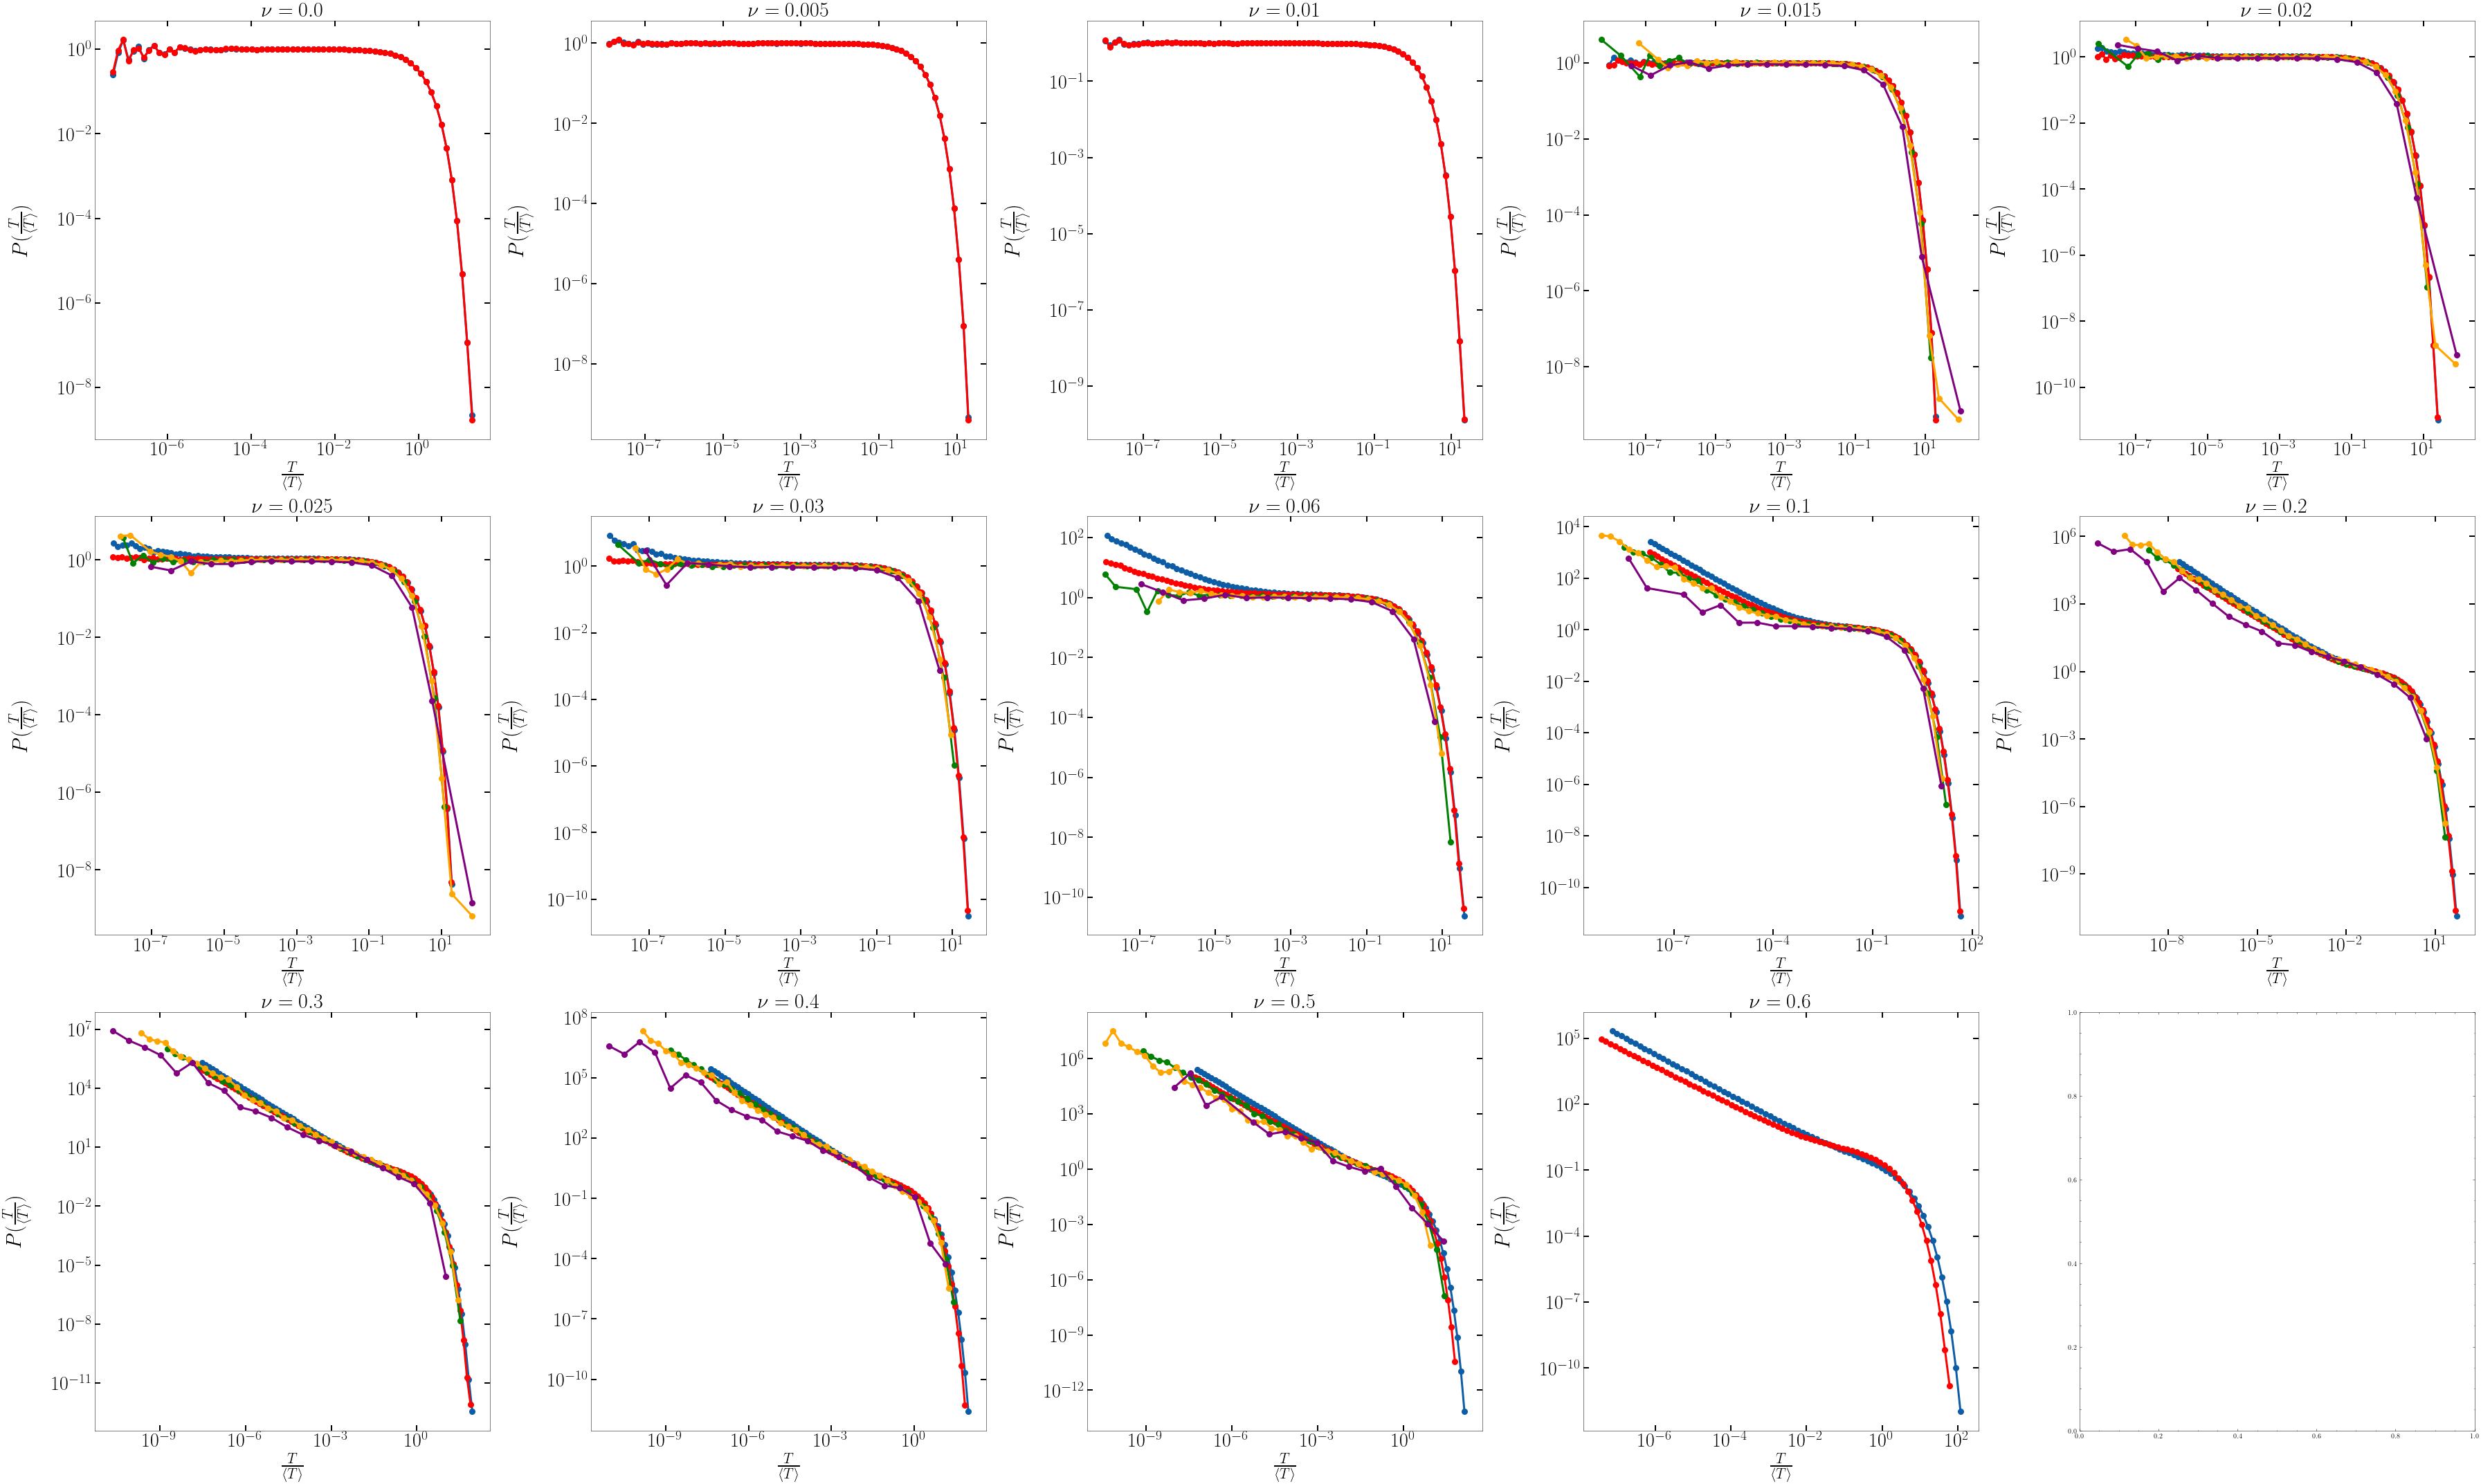

In [ ]:
fig, axis = plt.subplots(3,5, figsize = (50,30))
axis = axis.flatten()

for i in range(len(folderpath)):
    
    axis[i].plot(Thisto[i][ :, 0], Thisto[i][ :, 1], color = 'C0', linewidth = 3, marker = 'o', markersize = 8)
    axis[i].plot(Thisto2[i][ :, 0], Thisto2[i][ :, 1], color = 'red', linewidth = 3, marker = 'o', markersize = 8)
    
    if (i >=3) and (i < 13):
        axis[i].plot(Thisto10[i-3][ :, 0], Thisto10[i-3][ :, 1], color = 'green', linewidth = 3, marker = 'o', markersize = 8)
        axis[i].plot(Thisto100[i-3][ :, 0], Thisto100[i-3][ :, 1], color = 'orange', linewidth = 3, marker = 'o', markersize = 8)
        axis[i].plot(Thisto1000[i-3][ :, 0], Thisto1000[i-3][ :, 1], color = 'purple', linewidth = 3, marker = 'o', markersize = 8)
    
    para_fig(axis[i], r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog')
    axis[i].set_title(r"$\nu = {}$".format(Tvar[i]), fontsize = 30)

plt.tight_layout()
plt.show()

### Par magnitude


In [2]:
def process_time_magnitude(folder, class_range, nbins = 100, limdata = 1e7):
    nbrange = len(class_range)
    histo = np.zeros((nbrange, nbins))
    bins = np.logspace(np.log10(10**-12), np.log10(10**2), nbins + 1)
    csize = 1e7
    nbdata = 0
    
    last_ava_time = 0
    last_ava_inrange = np.zeros((nbrange, 1,2))
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols = [1,3]):
        
        data = np.column_stack((np.cumsum(chunk.iloc[:, 1]), chunk.iloc[:,0]))
        data[:,0] += last_ava_time #rebuild the time scale starting from zero using dz
        last_ava_time = data[-1,0]
        
        for i, range in enumerate(class_range):
            data_inrange = data[range(data[:,1])]
            data_inrange = np.vstack((last_ava_inrange[i],data_inrange)) #add the last avalanches from the previous chunk
            last_ava_inrange[i] = data_inrange[-1]
        
            if(len(data_inrange) > 0):
                diff_time = np.diff(data_inrange[:,0]) #Calculate the difference in time between avalanches
                histo[i] += np.histogram(diff_time, bins = bins)[0]
          
          
            
        nbdata+=len(chunk)
        if nbdata >= limdata: break
    
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.array([np.sum(h * bin_centers) / np.sum(h) for h in histo]) # (sum(x * w)/sum(x))
    norm_histo = np.array([h/(np.diff(bins) * np.sum(h)) for h in histo]) #Calculate the density probability of the distribution (area =1) (h/(largeur des bins * somme des bins)
    norm_histo = np.array([h*m for h, m in zip(norm_histo, mean)]) #Normalize the histogram with the mean of the distribution (y)
    norm_bin_centers = np.array([bin_centers/m for m in mean]) #Normalise the bins (x)

    
    return  norm_bin_centers, norm_histo, mean

In [3]:

limdata = 1e8
nbins = 25
class_range = [lambda x : (x >= 1) & (x < 10),
               lambda x : (x >=10) & (x < 1000),
               lambda x : (x >= 1000)]

islice = slice(3, -1)
results_mag = Parallel(n_jobs=-1)(delayed(process_time_magnitude)(folder,class_range, nbins, limdata) for folder in folderpath[islice])


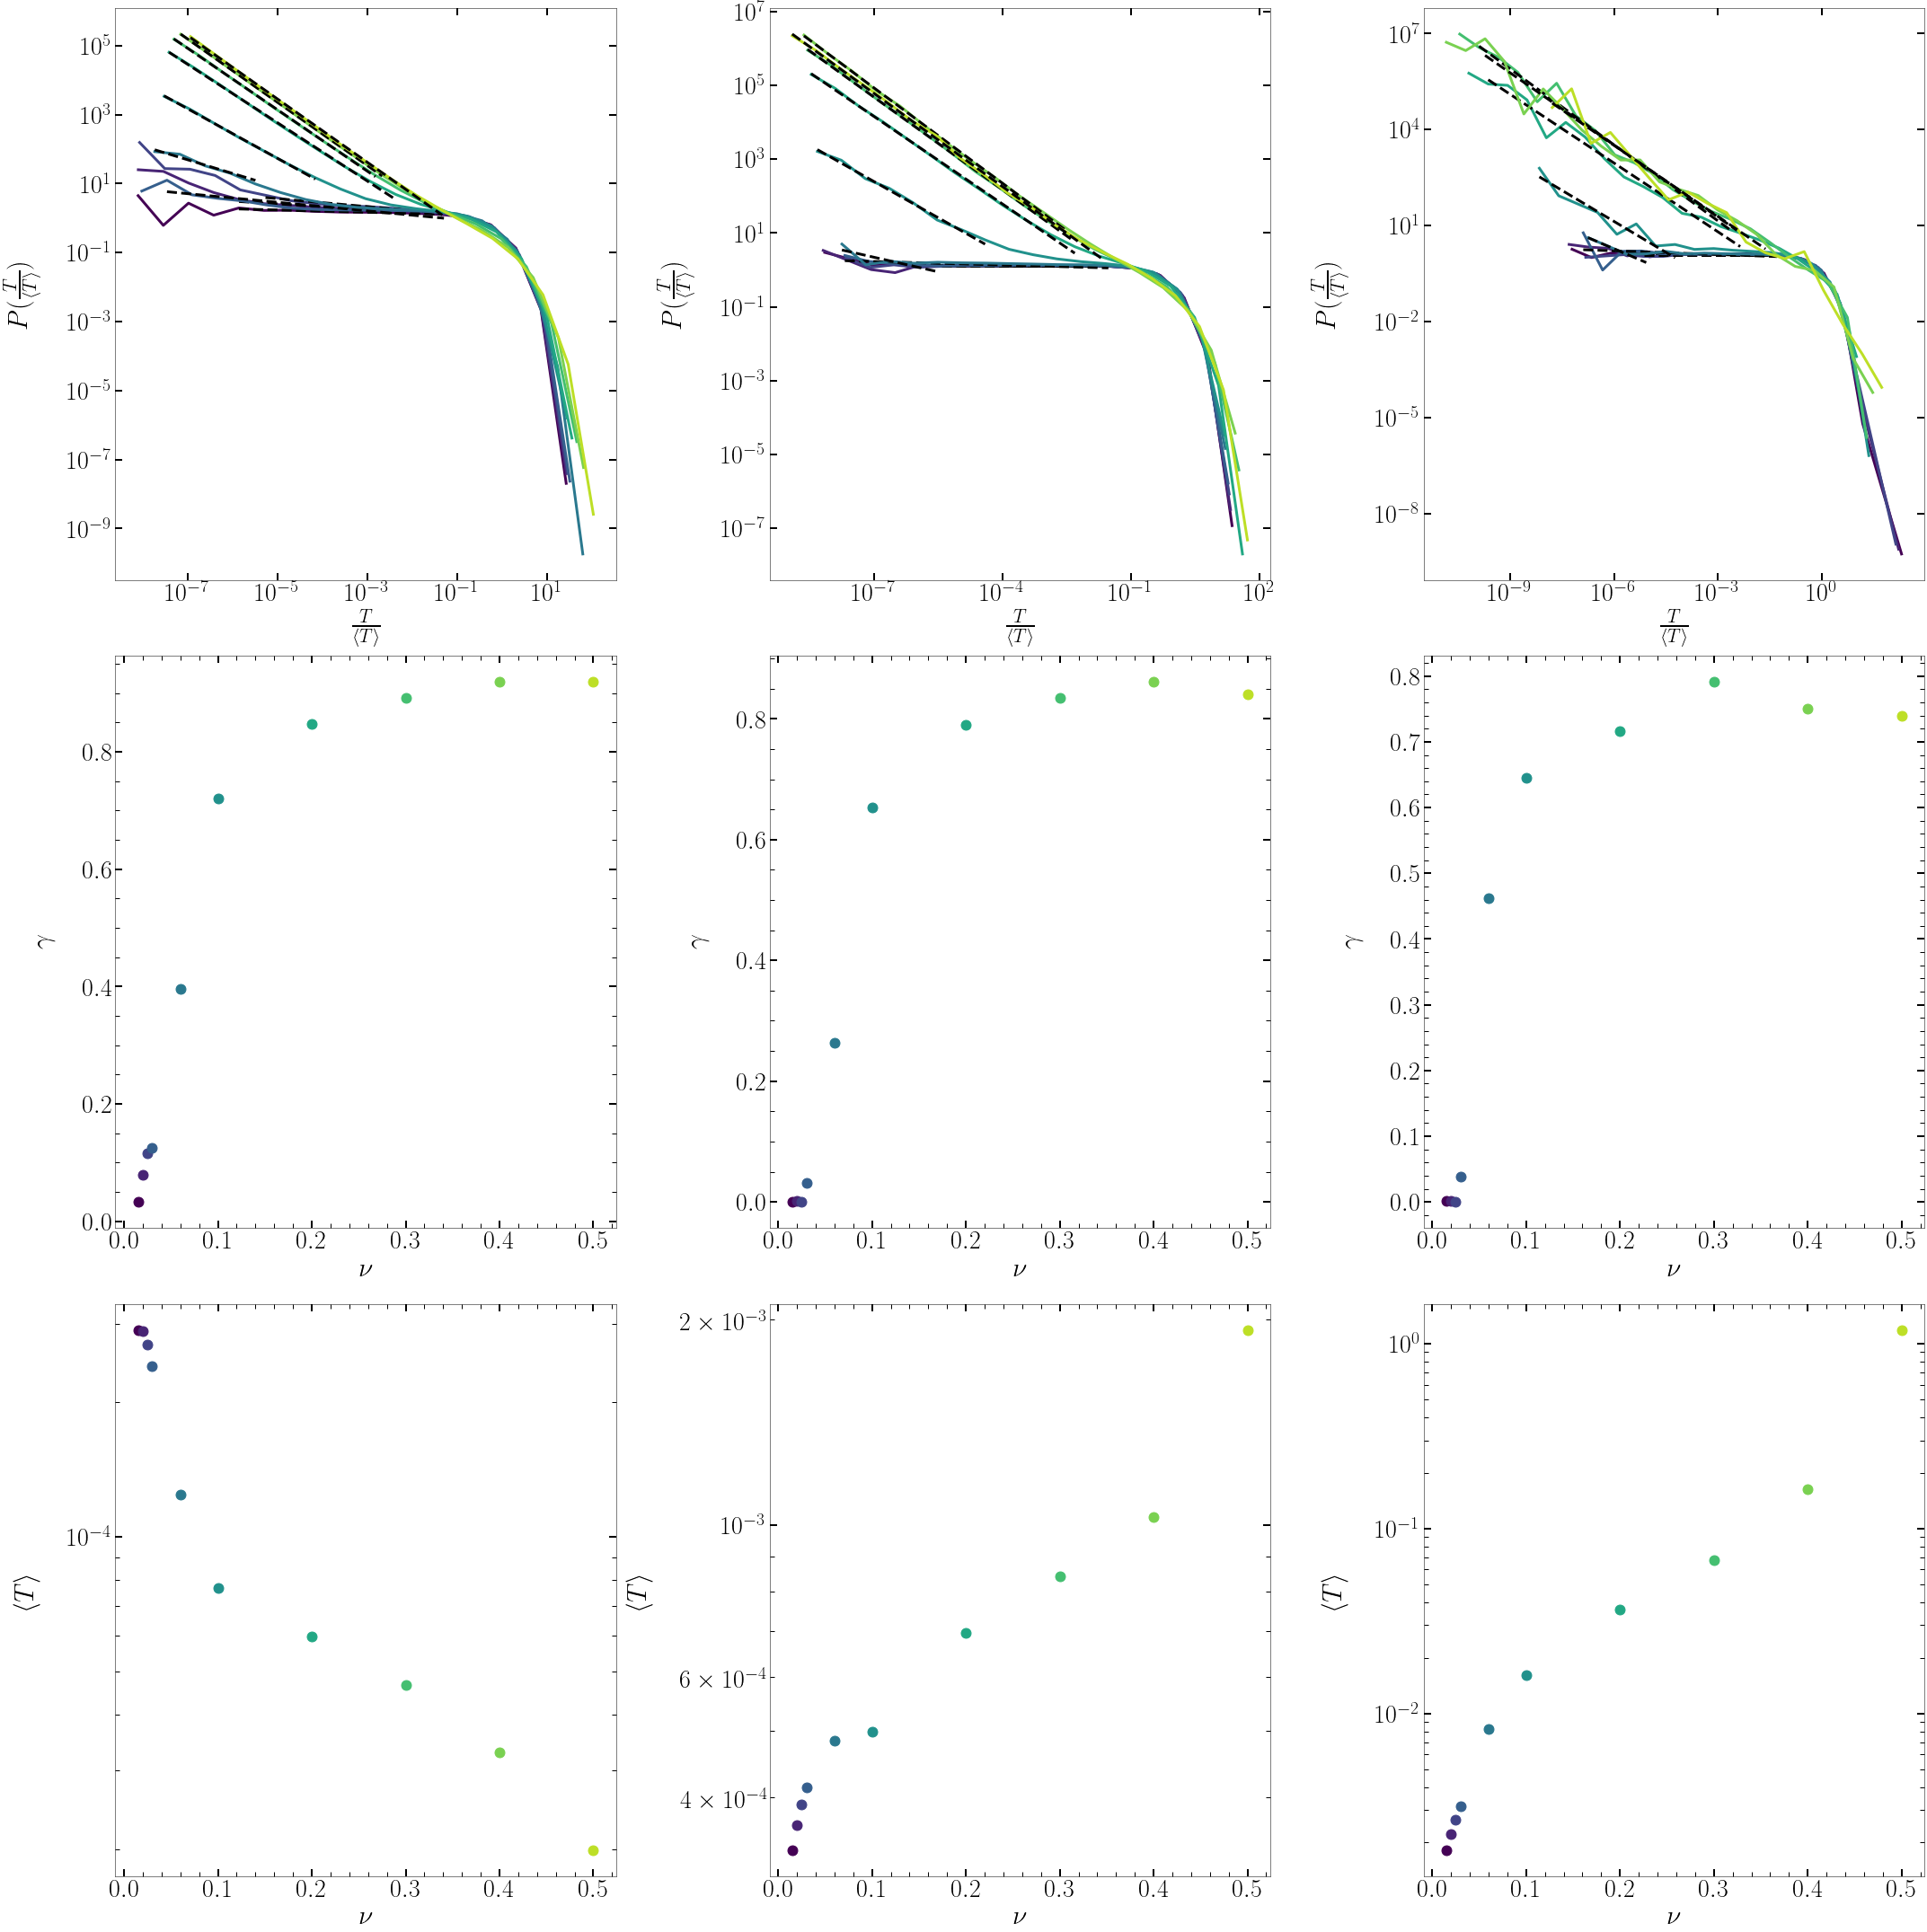

In [6]:
Tstart_x = [2e-6,1e-6,1e-6,1e-6,1e-6,
           2e-6,1e-8,1e-10,1e-10,1e-10,
           1e-10,1e-10,1e-10,1e-10]

Tstop = [1e-1,1e-1,1e-1,1e-1,1e-1,
        1e-1,1e-1,1e-5,1e-4,1e-2,
        5e-3,5e-3,5e-2,2e-3]

nbclass = len(class_range)

Tbins= np.zeros((len(Tvar[islice]),nbclass, nbins))
Thisto = np.zeros((len(Tvar[islice]),nbclass, nbins))
Tmean = np.zeros((len(Tvar[islice]),nbclass))
for i, (Tbins_i, Thisto_i, Tmean_i) in enumerate(results_mag):
    Tbins[i] = Tbins_i
    Thisto[i] = Thisto_i
    Tmean[i] = Tmean_i

    
# Tbins, Thisto = results_mag[:,0], results_mag[:,1]
NCURVES = len(Tvar[islice])
colors = colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

fig, ax = plt.subplots(3, 3, figsize=(30,30))
for i, (bins, histo, start_x, stop, mean) in enumerate(zip(Tbins, Thisto, Tstart_x[islice], Tstop[islice], Tmean)):
    for c in range(len(class_range)):
        filtered_bins = bins[c][histo[c] > 0]
        filtered_histo = histo[c][histo[c] > 0]
        
        result, xs, _ , perr = fit_powerlaw(filtered_bins, filtered_histo, stop_x = stop, start_x = start_x, f_scale=1.0,
                                    function_to_fit='power', switch = 1)
        
        ax[0,c].plot(filtered_bins, filtered_histo, color=colors[i], lw = 3)
        ax[0,c].plot(xs, powerlaw(xs, *result.x), color='k', ls = '--', lw = 3)
        ax[1,c].scatter(Tvar[islice][i], -np.round(result.x[1], 3), color = colors[i], s = 120)
        ax[2,c].scatter(Tvar[islice][i], mean[c], color = colors[i], s = 120)
        # ax[c].axvline(1, color='k', linestyle='--', lw = 2)
        # ax[c].axhline(1, color='k', linestyle='--', lw = 2)

for c in range(len(class_range)):        
    para_fig(ax[0, c],  r'$\frac{T}{\langle T \rangle}$', r'$P(\frac{T}{\langle T \rangle})$', type = 'loglog')
    para_fig(ax[1,c], r'$\nu$', r'$\gamma$')
    para_fig(ax[2,c], r'$\nu$', r'$\langle T \rangle$', type = 'semilog')
    
plt.tight_layout()
plt.show()
        
        

### Distribution cumulative

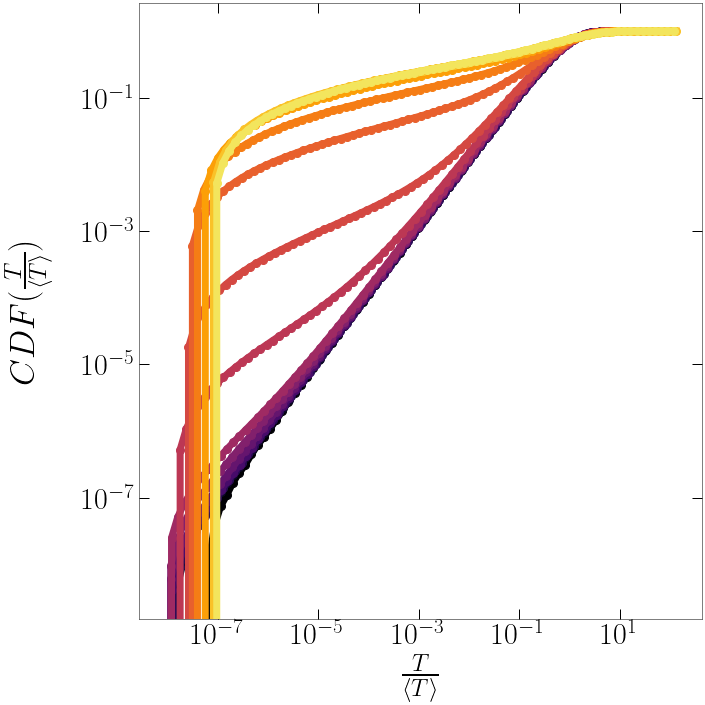

In [9]:
from scipy.integrate import cumtrapz

Tcdf = [cumtrapz(histo[:,1], histo[:,0], initial=0) for histo in Thisto_it]
Tcdf = [cdf/cdf[-1] for cdf in Tcdf]

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

fig, ax1 = plt.subplots(figsize = (10, 10))
for j, (bins_histo, cdf) in enumerate(zip(Thisto_it, Tcdf)):
    bins = bins_histo[:,0]
    ax1.plot(bins, cdf, color = colors[j], lw = 7, marker = 'o', markersize = 8)


para_fig(ax1, r'$\frac{T}{\langle T \rangle}$', r'$CDF(\frac{T}{\langle T \rangle})$', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)
ax1.set_xscale('log')
ax1.set_yscale('log')
# ax1.set_ylim(0.1,1.2)
plt.tight_layout()
plt.show()


## Average intertime

In [2]:
def process_meantime_th(folder, minsize, limdata = 1e9):

    csize = 1e7
    nbdata = 0
    
    lasttime = 0
    last_filtered_time = 0
    norm = 0
    suminter  = 0
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols = [1,3]):
        
        time = np.array(np.cumsum(chunk.iloc[:, 1])) + lasttime #rebuild the time scale starting from zero using dz
        lasttime = time[-1]  #Save the time for the next chunk
        # filterd_chunk = chunk.iloc[:, 1][chunk.iloc[:, 0] >= minsize]
        
        filtered_time = time[chunk.iloc[:, 0] >= minsize] #Keep only the avalanches with a size above a threshold
        filtered_time = np.insert(filtered_time, 0, last_filtered_time) #add to the array the time of the last avalanches from the previous chunk
        last_filtered_time = filtered_time[-1]  #Keep the time of the last avalanches for the next chunk
        
        if(len(filtered_time) > 0):
            time_inter = np.diff(filtered_time)
            
            suminter += np.sum(time_inter)
            norm += len(time_inter)
            
        nbdata+=len(time)
        
        if nbdata >= limdata: break
        
        
    # histo = histo/nbdata
    mean = suminter/norm
        
    return mean
        

### S = 1 (histogram is used)

In [3]:
def process_meantime(folder, nbins):
    histo = np.loadtxt(f"{folder}/stat_histoitime.txt", comments = "#")
    bins = np.logspace(np.log10(10**-12), np.log10(2), nbins)

    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)
    
    return mean

In [4]:
nbins = 1000
results = Parallel(n_jobs=-1)(delayed(process_meantime)(folder, nbins + 1)
                                  for folder in folderpath)

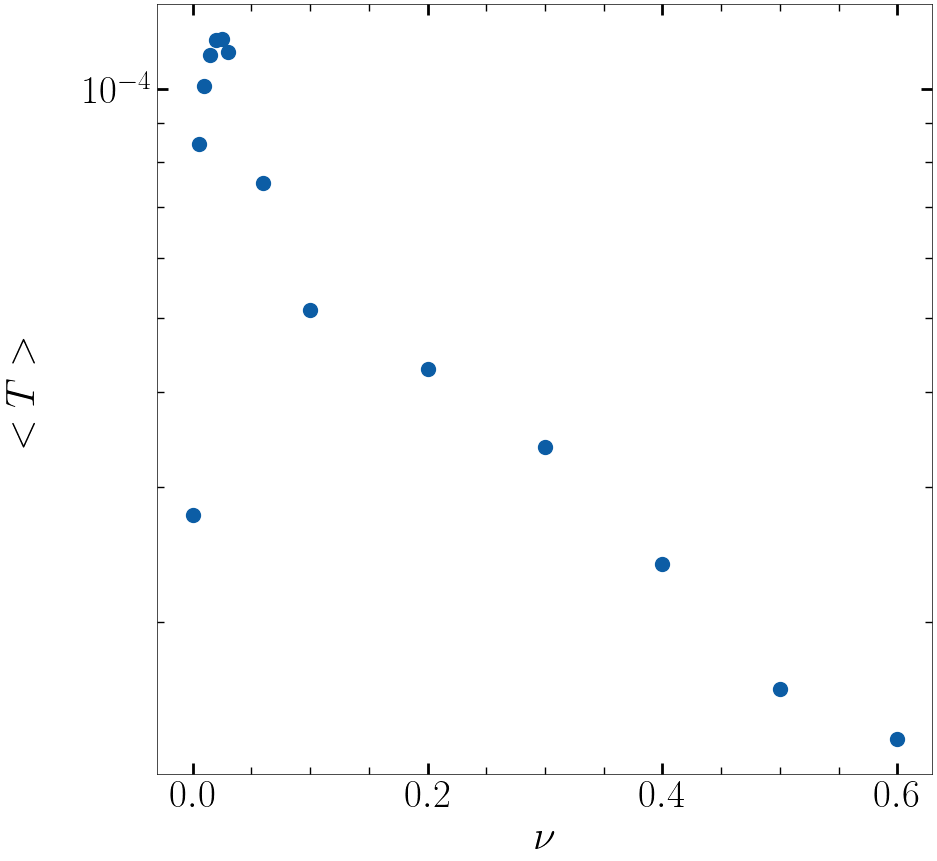

In [5]:
mean = results

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar, mean, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()
# semilogfig_scatter(Tvar, mean, r"$\nu$", r"$<T>$")

### S = 2 (Sample is used)

In [6]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

folderpathbis = folderpath
for i in range(1,7):
    folderpathbis[i-1] = "/data1/DATA_Duplat/Brut/PDF/PD7n{}".format(i)

print(Tvar)
limdata = 1e8
minsize = 2
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpath[:])

[0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.06, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]


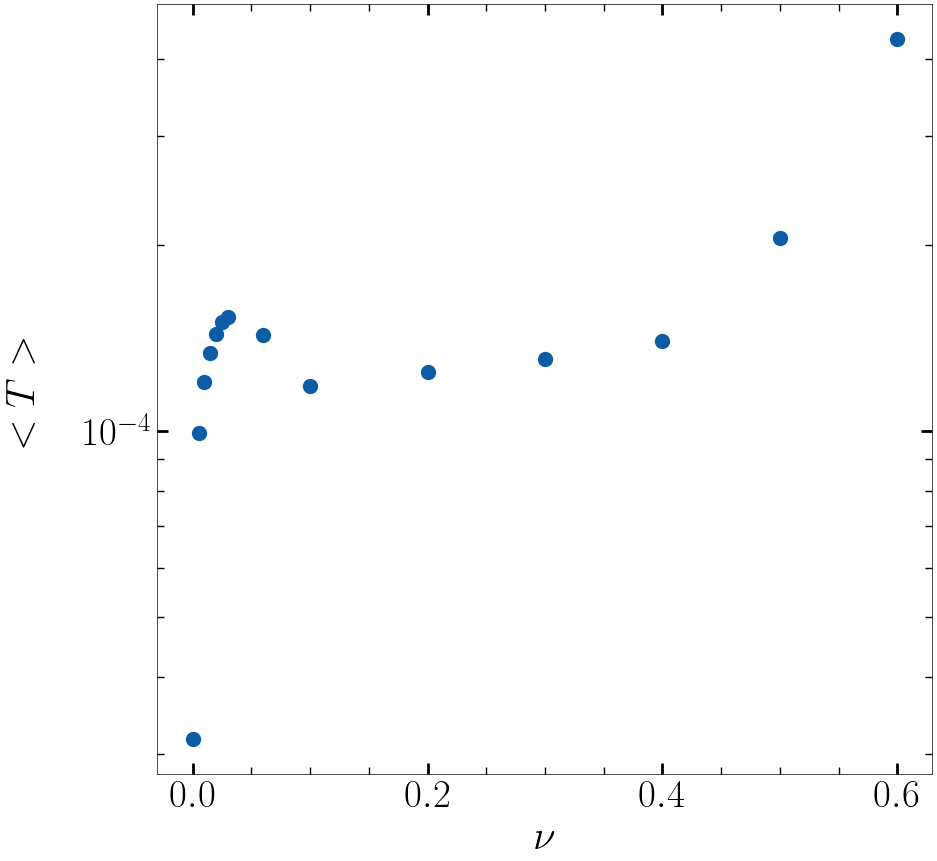

In [7]:
mean2 = results

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar[:], mean2, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()

### S = 10

In [8]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 10
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpathbis[:])

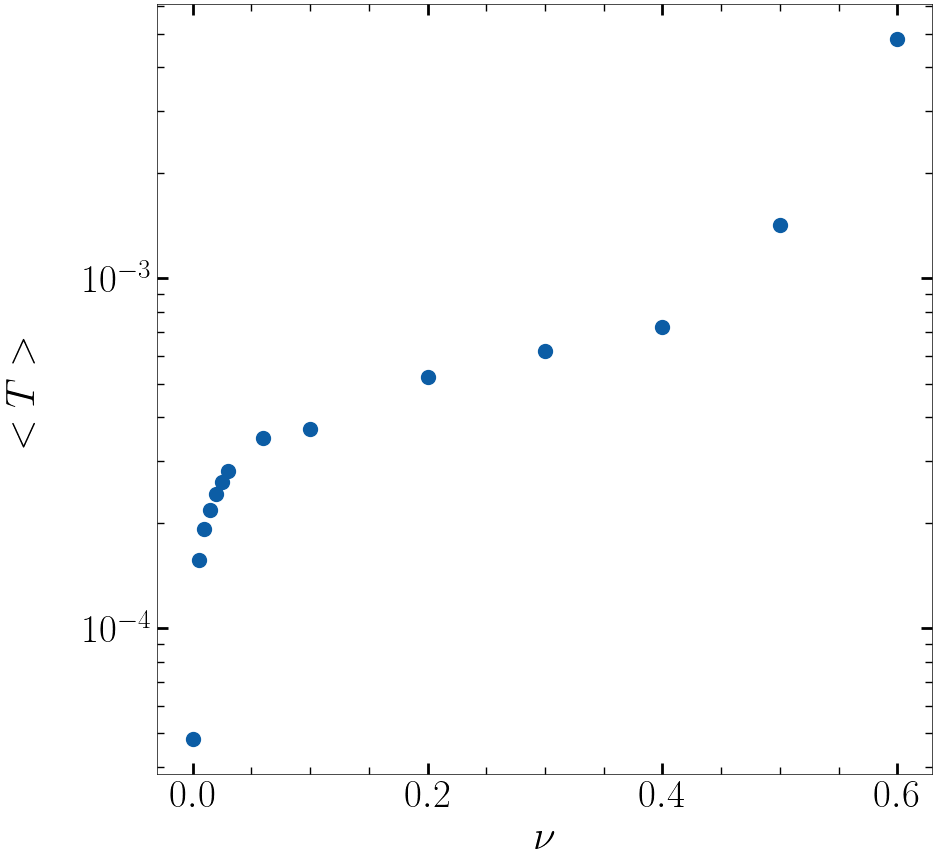

In [9]:
mean10 = results

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar[:], mean10, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()

### S = 100

In [10]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 100
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpathbis[:])

/home/kduplat/Documents/py38/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


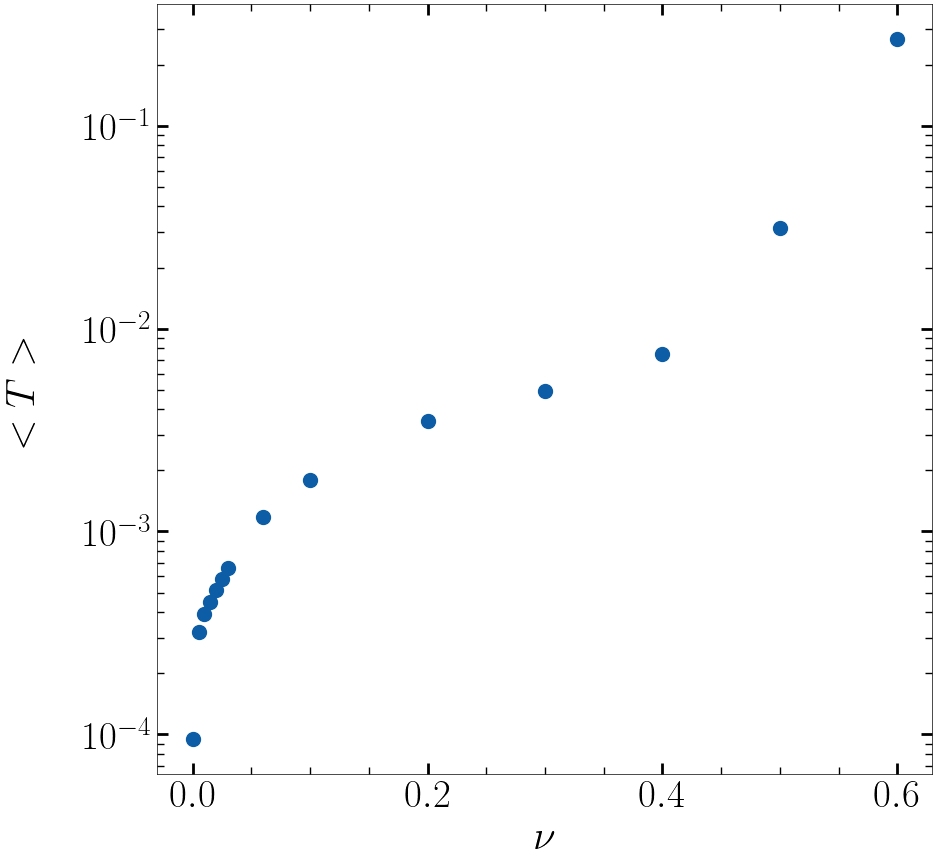

In [11]:
mean100 = results

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar[:], mean100, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()

### S = 1000

In [12]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 1000
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpathbis[:])

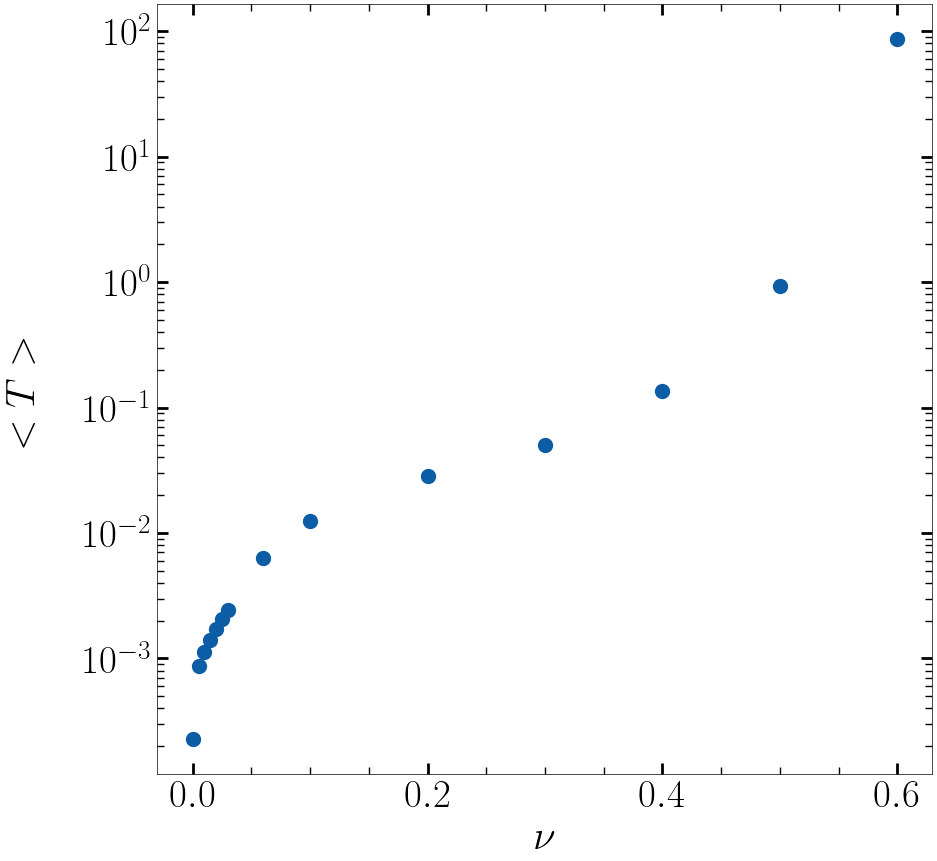

In [13]:
mean1000 = results

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar[:], mean1000, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()

### S >=N/10

In [14]:
limdata = 1e8
minsize = (L1 * L2)/10
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpathbis)

/tmp/ipykernel_2408545/65331427.py:33: RuntimeWarning: invalid value encountered in scalar divide


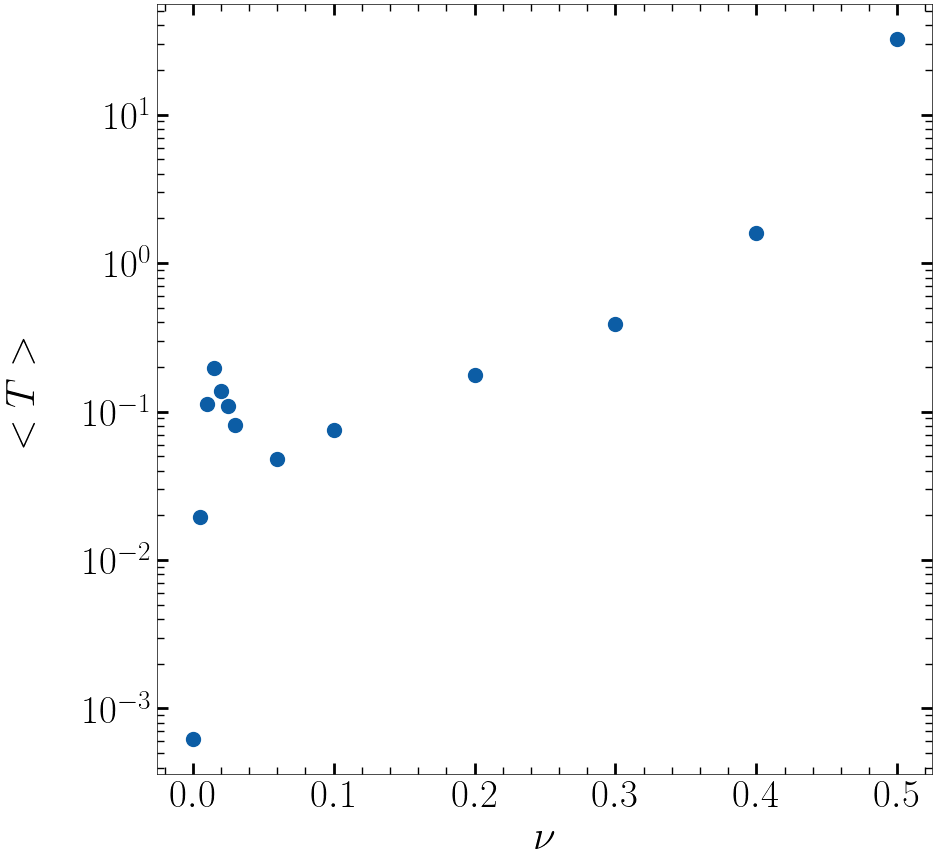

In [15]:
meanN10 = results

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar, meanN10, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()

### S = 10000

In [14]:
# fnb = np.arange(1,14)
# folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
# Tvar = [read_parameters(folder)[2] for folder in folderpath]

limdata = 1e8
minsize = 10000
results = Parallel(n_jobs=-1)(delayed(process_meantime_th)(folder, minsize, limdata)
                                  for folder in folderpathbis[:])

/tmp/ipykernel_3913235/65331427.py:33: RuntimeWarning: invalid value encountered in scalar divide


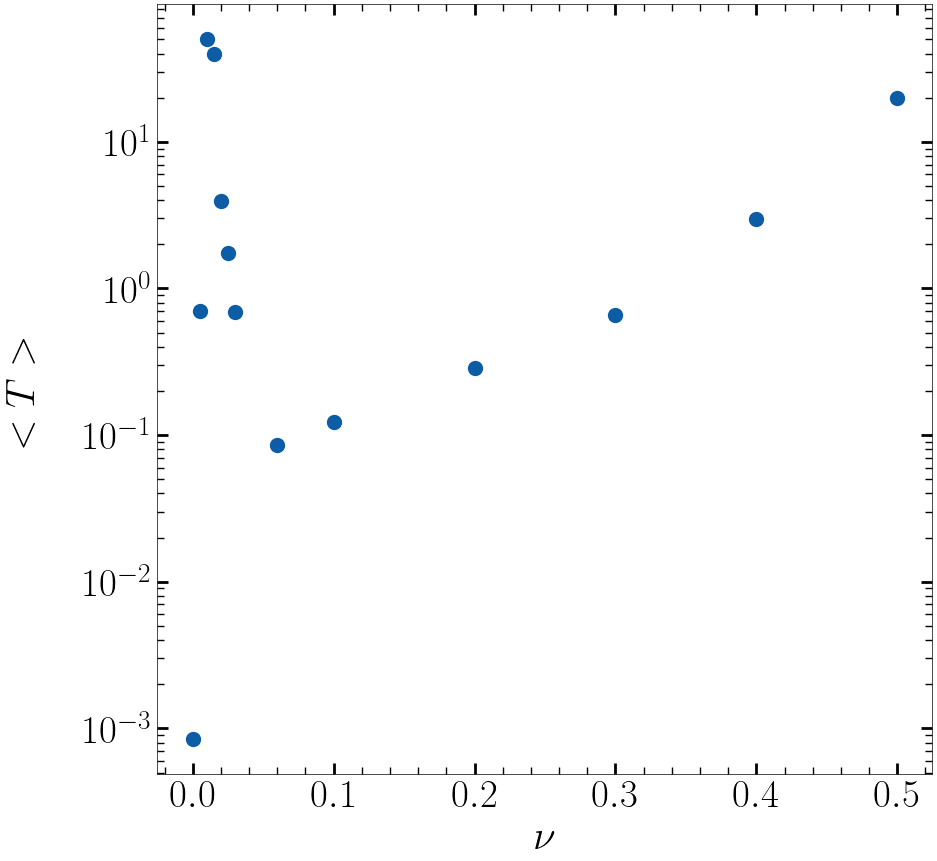

In [15]:
mean10000 = results

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar[:], mean10000, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()

### Récap

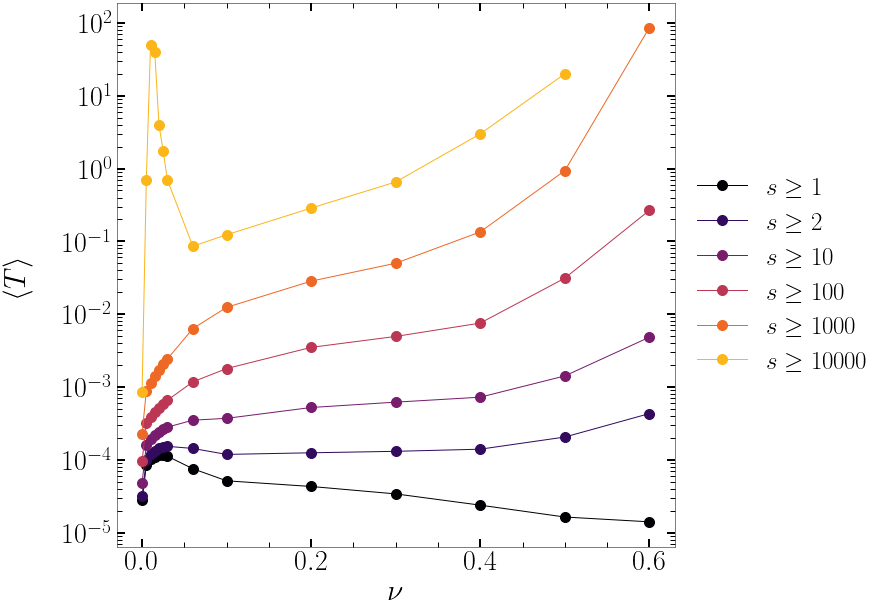

In [36]:
NCURVES = 6
cmap = plt.cm.get_cmap('inferno') 
colors = [cmap(i / NCURVES) for i in range(NCURVES)]


plt.figure(figsize = (10,10))
plt.plot(Tvar, mean, markersize = 10, marker = 'o', color = colors[0], label = r"$s \geq  1$")
plt.plot(Tvar[:], mean2, markersize = 10, marker = 'o', color = colors[1], label = r"$s \geq  2$")
plt.plot(Tvar[:], mean10, markersize = 10, marker = 'o', color = colors[2], label = r"$s \geq  10$")
plt.plot(Tvar[:], mean100, markersize = 10, marker = 'o', color = colors[3], label = r"$s \geq  100$")
plt.plot(Tvar[:], mean1000, markersize = 10, marker = 'o', color = colors[4], label = r"$s \geq  1000$")
plt.plot(Tvar[:], mean10000, markersize = 10, marker = 'o', color = colors[5], label = r"$s \geq  10000$")
plt.yscale("log")
plt.xlabel(r"$\nu$", fontsize=30)
plt.ylabel(r"$\langle T \rangle$", fontsize=30, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
# plt.legend(fontsize = 20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.show()

/tmp/ipykernel_3913235/662012741.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('inferno')


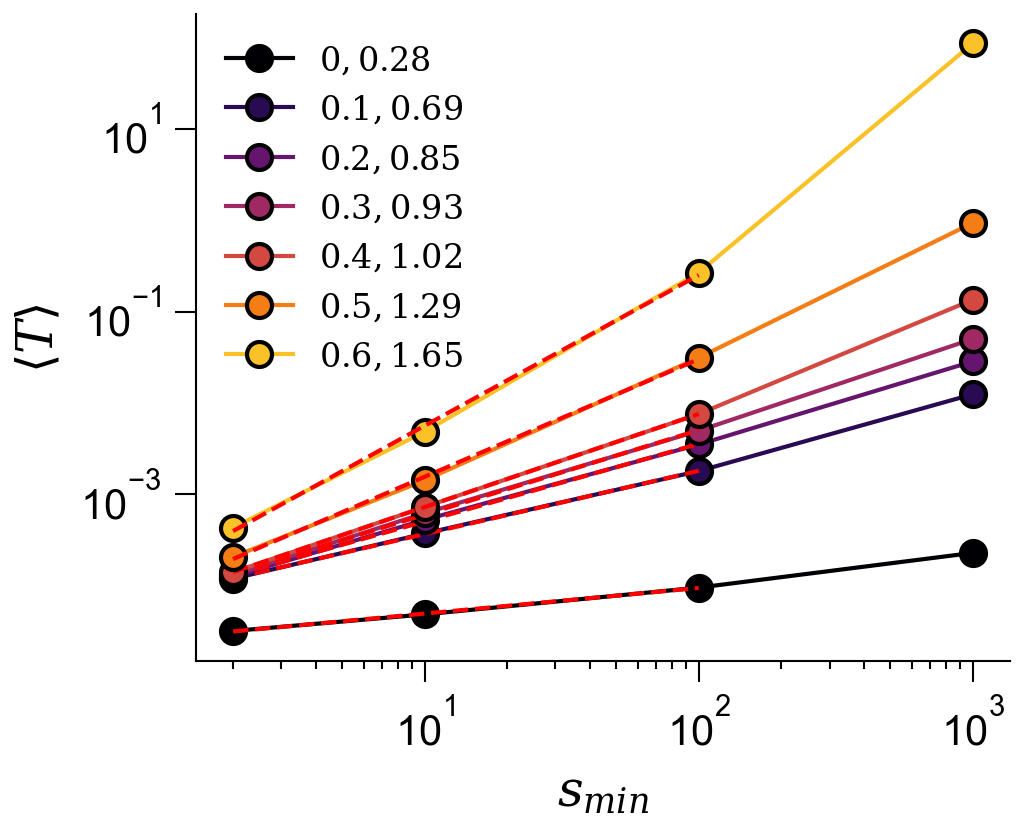

In [37]:
NCURVES = 7
cmap = plt.cm.get_cmap('inferno') 
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

id = [0,8,9,10,11,12,13]
Tsize = [2, 10,100,1000]
Tnu = [0, 0.1, 0.2,0.3,0.4,0.5,0.6]
with plt.style.context(spstyle.get_style('thesis')):
    fig, ax = plt.subplots(figsize = (3.5,2.8))
    for j, i in enumerate(id):
        Tmean = [mean2[i], mean10[i], mean100[i], mean1000[i]]

        popt,pcov = curve_fit(powerlaw2, np.log(Tsize[:-1]), np.log(Tmean[:-1]))
        yfit = np.exp(powerlaw2(np.log(Tsize[:-1]), *popt))
        ax.plot(Tsize, Tmean, marker = 'o', color = colors[j], label = r"${}, {}$".format(Tnu[j], np.round(popt[1], 2)))
        ax.plot(Tsize[:-1], yfit, ls ='--', c = 'r')
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel(r"$s_{min}$")
    ax.set_ylabel(r"$\langle T \rangle$")
    ax.legend()

    plt.show()

### mean T for s>1000 norm by mean T for all s

(14,)
(14,)
(14,)


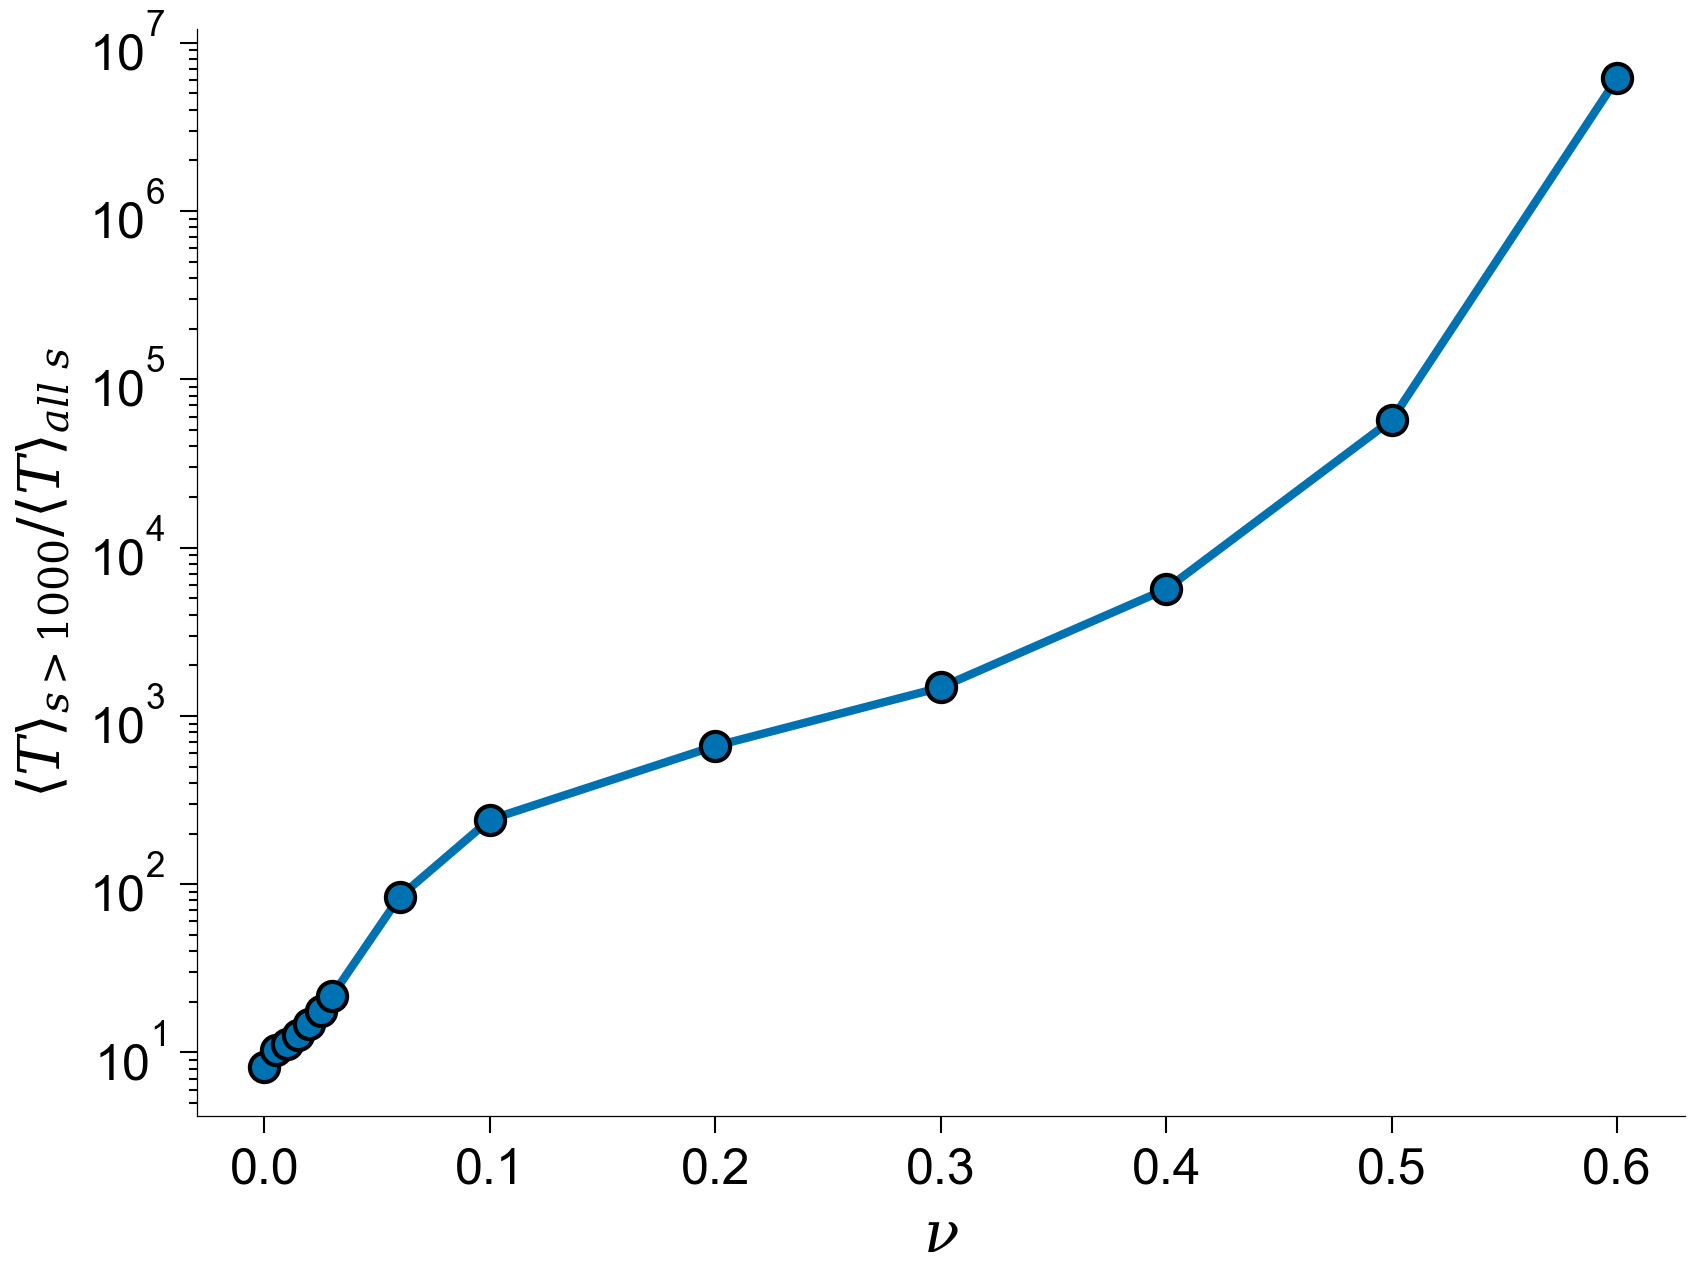

In [33]:
""" plt.figure(figsize = (10,10))

plt.plot(Tvar[:-1], np.array(mean1000)/np.array(mean[:-1]), markersize = 10, marker = 'o', color = colors[4], label = r"$s \geq  1000$")

plt.yscale("log")
plt.xlabel(r"$\nu$", fontsize=30)
plt.ylabel(r"$\langle T \rangle_{s > 1000} / \langle T \rangle_{all~s}$", fontsize=30, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
# plt.legend(fontsize = 20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25)
plt.s
plt.show() """

print(np.shape(Tvar))
print(np.shape(np.array(mean1000)))
print(np.shape(np.array(mean)))

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (6.4, 4.8))

    plt.plot(Tvar, np.array(mean1000)/np.array(mean), marker = 'o', color = '#0072b2', label = r"$s \geq  1000$")

    plt.yscale("log")
    plt.xlabel(r"$\nu$")
    plt.ylabel(r"$\langle T \rangle_{s > 1000} / \langle T \rangle_{all~s}$",)

    # plt.legend(fontsize = 20)
    """ plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) """
    plt.savefig('FigT1000overT1.pdf', dpi = 300)
    plt.show()

### mean T for s>N/10 norm by mean T for all s

(14,)
(14,)
(14,)
[6.20677456e-04 1.95295452e-02 1.12166337e-01 1.95098140e-01
 1.37245871e-01 1.09042734e-01 8.09804060e-02 4.77731778e-02
 7.54726971e-02 1.77685172e-01 3.91531819e-01 1.59761233e+00
 3.22226701e+01            nan]


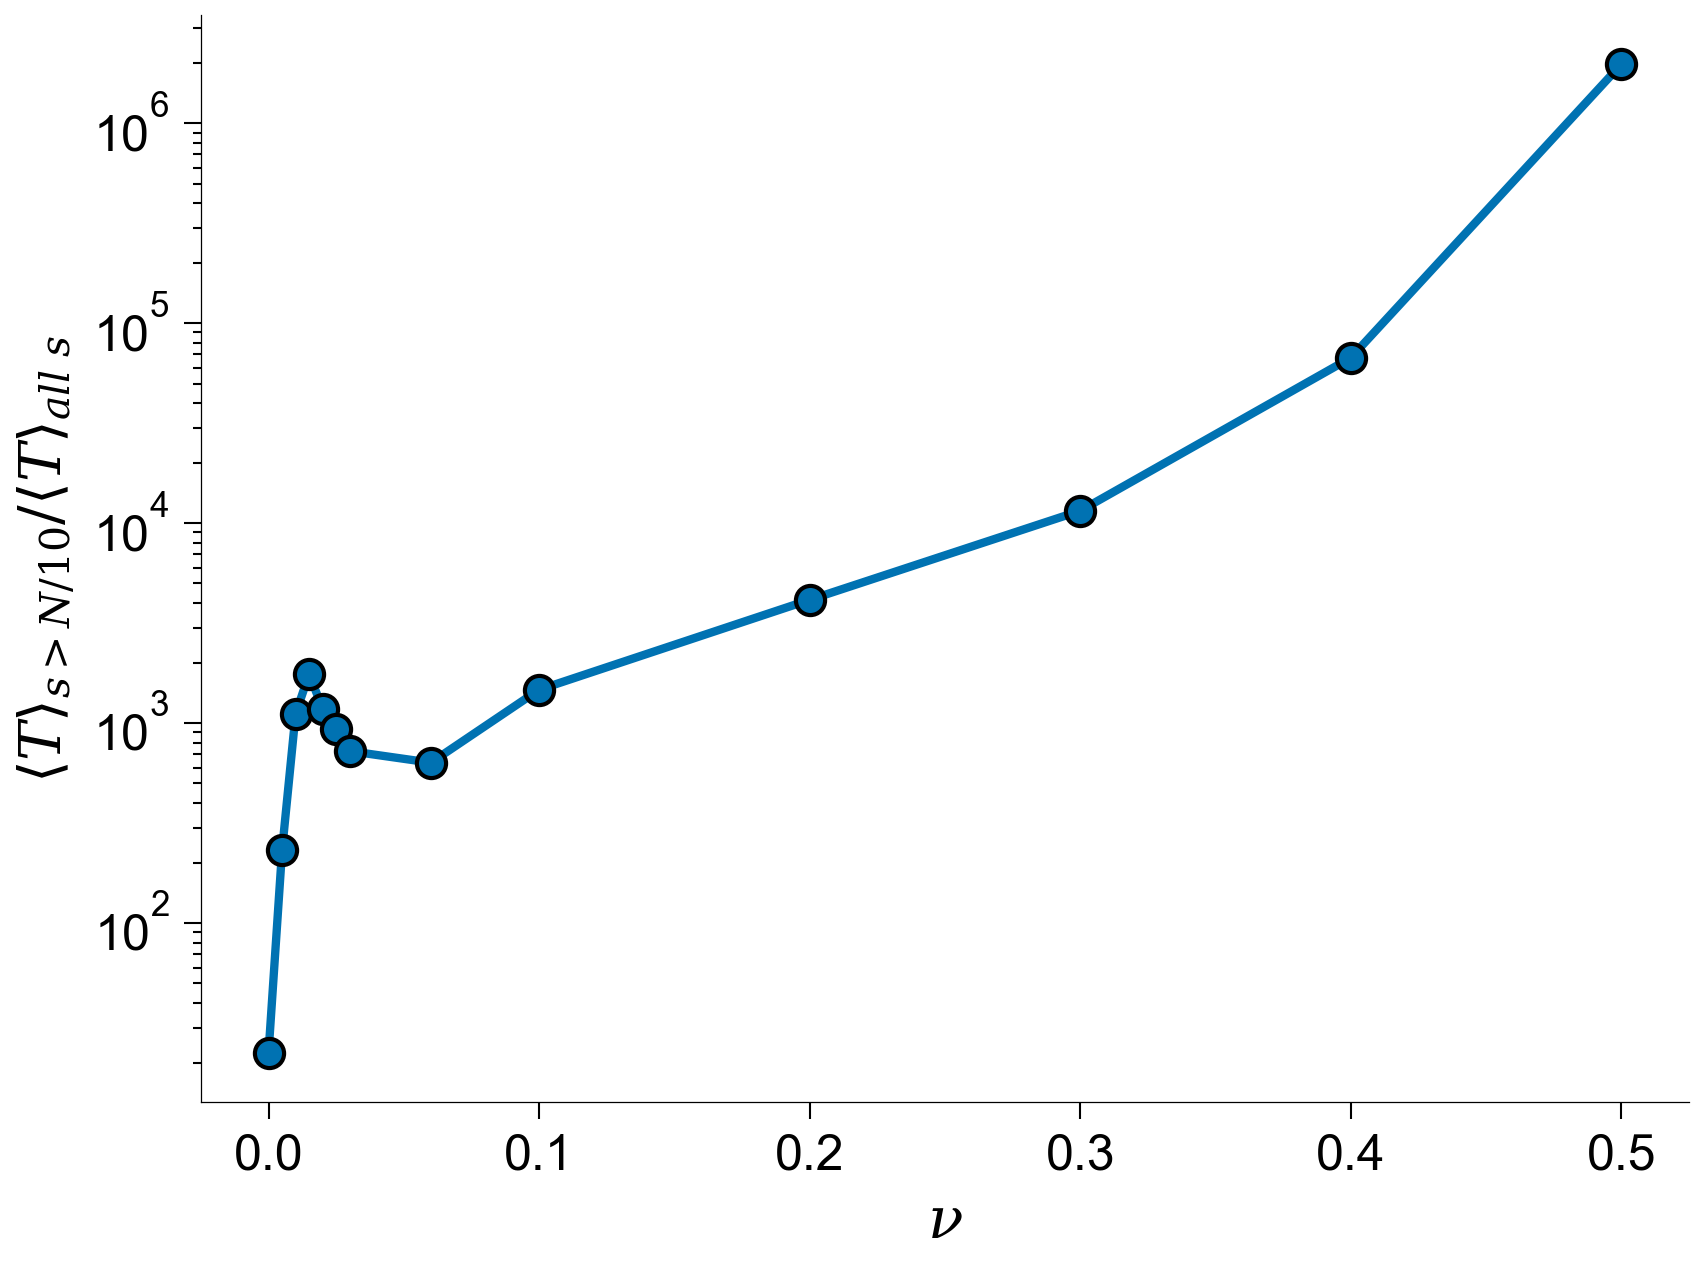

In [34]:
print(np.shape(Tvar))
print(np.shape(np.array(meanN10)))
print(np.shape(np.array(mean)))

print(np.array(meanN10))

with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (6.4, 4.8))

    plt.plot(Tvar, np.array(meanN10)/np.array(mean), marker = 'o', color = '#0072b2', label = r"$s \geq  N/10$")

    plt.yscale("log")
    plt.xlabel(r"$\nu$")
    plt.ylabel(r"$\langle T \rangle_{s > N/10} / \langle T \rangle_{all~s}$",)

    # plt.legend(fontsize = 20)
    """ plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) """
    plt.savefig('FigTN10overT1.pdf', dpi = 300)
    plt.show()

### 5e2<s< 1e3

In [5]:
def process_meantime_and_toppling_window(folder, minsize = 5e2, maxsize = 1e3, limdata = 1e9):

    histo = np.zeros(nbins)
    bins = np.logspace(np.log10(10**-12), np.log10(10**2), nbins + 1)
    csize = 1e7
    nbdata = 0
    
    lasttime = 0
    last_filtered_time = 0
    norm = 0
    suminter  = 0
    sumtop = 0
    norm_top = 0
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols = [1,3,4]):
        
        time = np.array(np.cumsum(chunk.iloc[:, 1])) + lasttime #rebuild the time scale starting from zero using dz
        toppling = np.array(chunk.iloc[:, 2])
        lasttime = time[-1]  #Save the time for the next chunk
        # filterd_chunk = chunk.iloc[:, 1][chunk.iloc[:, 0] >= minsize]
        mask = (chunk.iloc[:, 0] >= minsize) & (chunk.iloc[:, 0] <= maxsize)
        
        f_time = time[mask] #Keep only the avalanches with a size above a threshold
        f_toppling = toppling[mask]
        f_time = np.insert(f_time, 0, last_filtered_time) #add to the array the time of the last avalanches from the previous chunk
        last_filtered_time = f_time[-1]  #Keep the time of the last avalanches for the next chunk
        
        if(len(f_time) > 0):
            time_inter = np.diff(f_time)
            
            suminter += np.sum(time_inter)
            norm += len(time_inter)
            
            sumtop += np.sum(f_toppling)
            norm_top += len(f_toppling)
            
        nbdata+=len(time)
        
        if nbdata >= limdata: break
        
        
    # histo = histo/nbdata
    mean_it = suminter/norm
    mean_top = sumtop/norm_top
    
        
    return mean_it, mean_top

In [46]:
folderpathbis = folderpath
for i in range(6):
    folderpathbis[i] = "/data1/DATA_Duplat/Brut/PDF/PD7n{}".format(i+1)
    
limdata = 1e8
minsize = 5e2 
maxsize = 1e3
results = Parallel(n_jobs=-1)(delayed(process_meantime_and_toppling_window)(folder, minsize, maxsize,  limdata)
                                  for folder in folderpathbis[:-1])

In [47]:
mean_it, mean_top = np.array(results).T

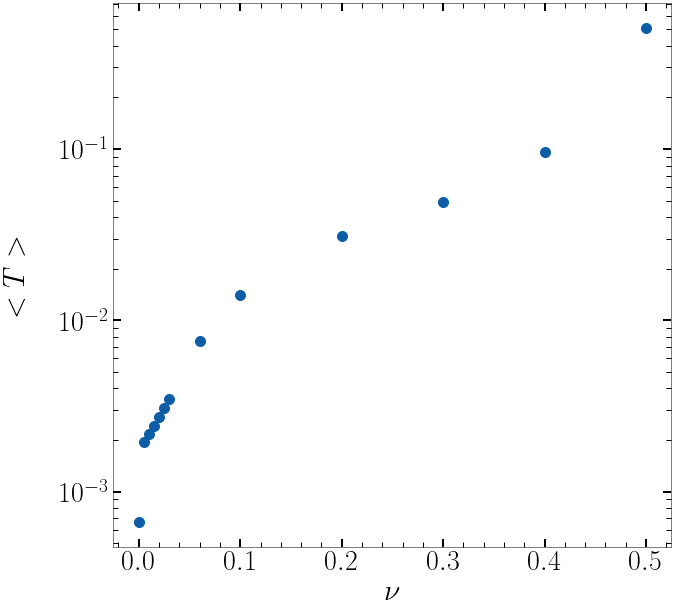

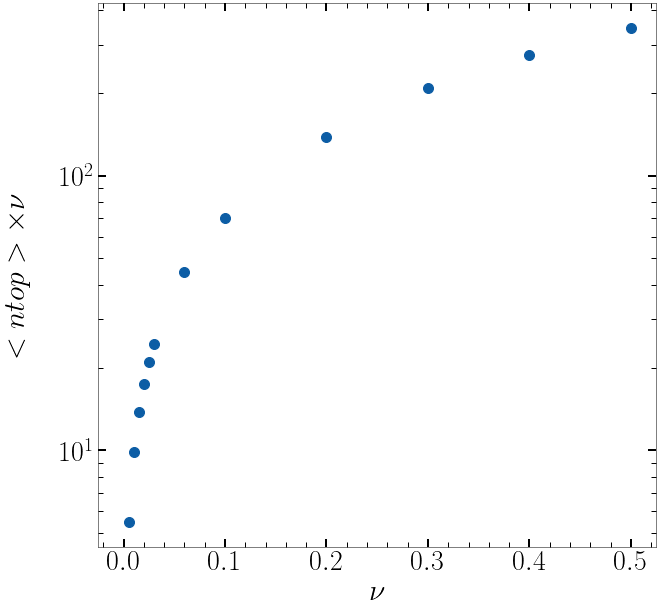

In [53]:
N = L1 * L2

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar[:-1], mean_it, s=100)
para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(Tvar[:-1], mean_top * Tvar[:-1], s=100)
para_fig(ax, r"$\nu$", r"$<ntop> \times \nu$", type = 'semilog')
plt.show()

# fig, ax = plt.subplots(figsize=(10, 10))
# ax.scatter(Tvar[:-1], mean_it - mean_top*Tvar[:-1], s=100)
# para_fig(ax, r"$\nu$", r"$<T>$", type = 'semilog')
# plt.show()

## Omori's law

In [5]:
def histoOmori(folder, nbins, bins, minsize, limdata):
    histo = np.zeros(nbins)

    csize = 1e7
    nbdata = 0
    
    begin = 0
    time = 0
    col = [1,3]
    
    maxtime = 1.5 * 10**-5
    
    def chunked_file_reader(filepath, chunksize=1e7, usecols=None):
        for chunk in pd.read_csv(filepath, compression='gzip', delim_whitespace=True, header=None, chunksize=chunksize, usecols=usecols):
            yield chunk
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=1e7, usecols=col):
        intertime = np.zeros(int(csize))
        for i, (s, dz) in enumerate(zip(chunk.iloc[:, 0], chunk.iloc[:, 1])):
            
            if begin == 0 and s < minsize: continue
            
            time += dz  
            if s >= minsize: 
                if begin == 0: begin = 1
                time = 0
            
            if time >= maxtime: continue
            intertime[i] = time
        
        intertime_filtered = intertime[intertime[:] != 0]
        histo += np.histogram(intertime_filtered, bins = bins)[0]
        nbdata+=len(chunk)
        
        if nbdata == limdata: break
        
        
    return histo

In [6]:
fnb = np.arange(1,14)
folderpath_omori = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
for i in range(6):
    folderpath_omori[i] = '/data1/DATA_Duplat/Brut/PDF/PD7n{}'.format(i+1)
minsize = 10
nbins = 50
limdata = 1e8
bins = np.logspace(np.log10(10**-9), np.log10(1), nbins + 1)

results = Parallel(n_jobs=5)(delayed(histoOmori)(folder, nbins, bins, minsize, limdata)
                                  for folder in folderpath_omori)


In [7]:
bins = np.logspace(np.log10(10**-9), np.log10(1), nbins + 1)
norm_histo = np.zeros((len(folderpath), nbins))
norm_histo_rescaled = np.zeros((len(folderpath), nbins))

histo = np.zeros((len(folderpath), nbins))

for i, result in enumerate(results):
    histo[i] = result

bin_centers = (bins[:-1] + bins[1:]) / 2
norm_bin_centers_rescaled = np.zeros((len(histo), len(bin_centers)))

    
for i in range(len(histo)):
    mean = np.sum(histo[i] * bin_centers) / np.sum(histo[i])
    norm_histo[i] = histo[i]/((np.diff(bins)) * np.sum(histo[i]))
    norm_histo_rescaled[i] = histo[i]/((np.diff(bins)) * np.sum(histo[i]))
    norm_bin_centers_rescaled[i] = bin_centers



<ipython-input-7-e270e581652f>:15: RuntimeWarning: invalid value encountered in double_scalars
  mean = np.sum(histo[i] * bin_centers) / np.sum(histo[i])
<ipython-input-7-e270e581652f>:16: RuntimeWarning: invalid value encountered in true_divide
  norm_histo[i] = histo[i]/((np.diff(bins)) * np.sum(histo[i]))
<ipython-input-7-e270e581652f>:17: RuntimeWarning: invalid value encountered in true_divide
  norm_histo_rescaled[i] = histo[i]/((np.diff(bins)) * np.sum(histo[i]))


Error


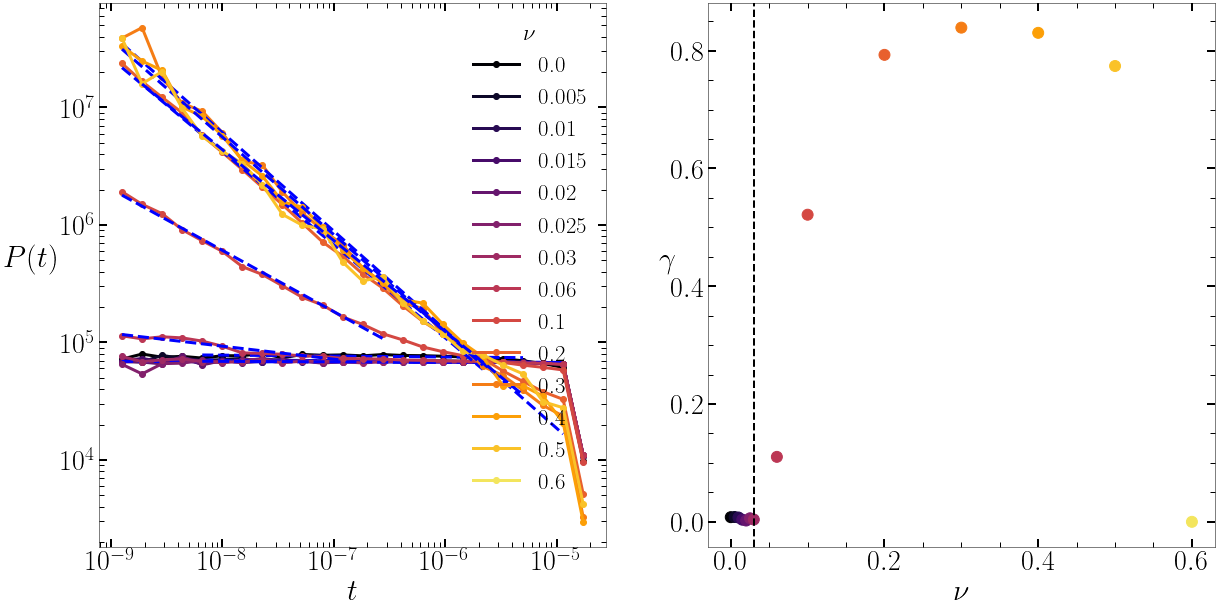

In [ ]:
NCURVES = len(folderpath) 
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]


vartab = [read_parameters(folder)[2] for folder in folderpath]
Txmin_pl = [10,14,10,10,0,12,10,2,0,0,0,0,4,0,0]
Txmax_pl = [45,48,48,48,48,48,48,25,30,40,48,40,44,48,48]

n = 12

Tb2 = np.zeros(len(folderpath))
Ta1 = np.zeros(len(folderpath))

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

# for i in range(len(folderpath)):
for i, (bins, histo, xmin_pl, xmax_pl) in enumerate(zip(norm_bin_centers_rescaled, norm_histo_rescaled, Txmin_pl,Txmax_pl)):
    mask = histo!= 0
    
    scal = len(bins[mask])/len(bins)
    

    ax1.plot(bins[mask], histo[mask], label = vartab[i], color = colors[i], lw = 3, marker = 'o')
    try: 
        
        s_xmin_pl = int(xmin_pl * scal)
        s_xmax_pl = int(xmax_pl * scal)
        
        
        mask2 = histo[s_xmin_pl:s_xmax_pl] !=0
        popt2, _ = curve_fit(powerlaw2, np.log(bins[s_xmin_pl:s_xmax_pl][mask2]), np.log(histo[s_xmin_pl:s_xmax_pl][mask2]))
        a2,b2 = popt2
        yfit2 = np.exp(powerlaw2(np.log(bins[s_xmin_pl:s_xmax_pl][mask2]), *popt2))
        Tb2[i] = b2


        ax1.plot(bins[s_xmin_pl:s_xmax_pl][mask2], yfit2, linestyle = "--", color = 'b', linewidth = 3)
    except ValueError:
        print("Error")
        continue 


ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r'$t$', fontsize=30)
ax1.set_ylabel(r'$P(t)$', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax1.legend(title = rf'$\nu$', fontsize = 23, title_fontsize = 23)

ax2.scatter(vartab, -Tb2, color = colors, s = 120, label = r'$\gamma$')
ax2.axvline(x = 0.03, color = 'k', ls = '--', lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')


plt.show()


## Propagation Time

In [ ]:
def process_tprop(folder, Lengthtab, nbins, nmin, nmax):
    data = np.loadtxt(f"{folder}/stat_histotprop.txt", comments = "#")
    
    last_non_zero = np.nonzero(data)[0]
    
    mean = np.sum(data * np.arange(len(data)))/np.sum(data)
    
    ndatafit, ndistloglog, nstat = mainfct(data, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean
    

In [ ]:
Tnmin = np.array([1,1, 1,1,1,1,1, 1,3,3,3,5, 5, 5])
Tnmax = np.array([60,40,40,40,40,40,40, 60,60,60,60,60,60, 60])
nbins = 100
lengthtab = L1 * L2 * 1000

results = Parallel(n_jobs=-1)(delayed(process_tprop)(folder, lengthtab, nbins, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))

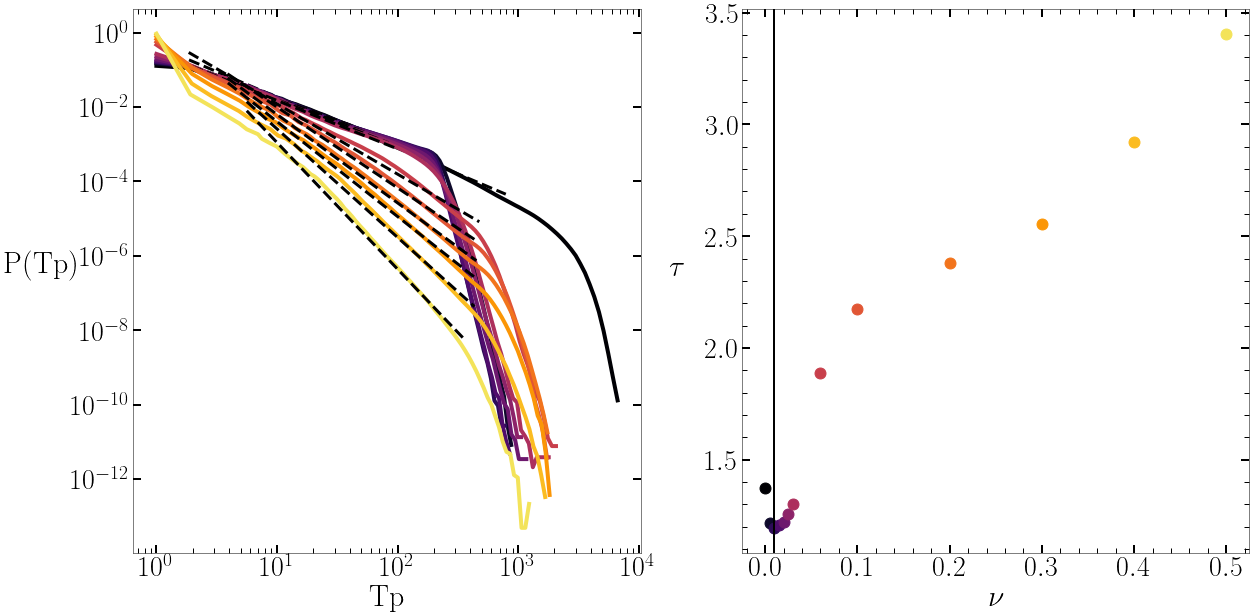

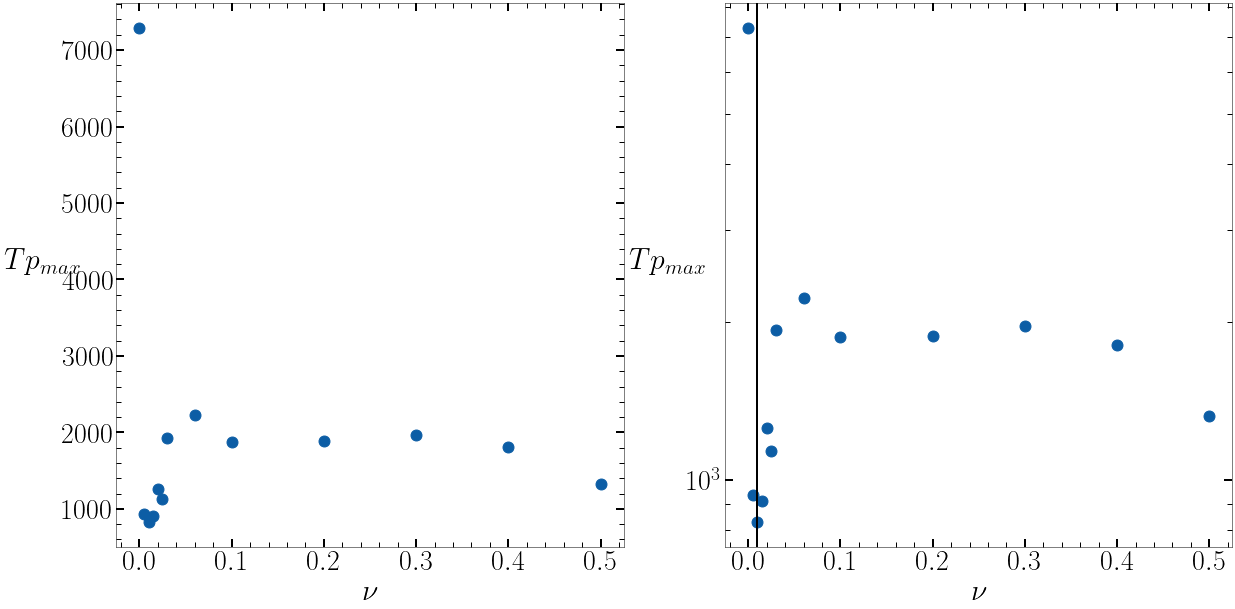

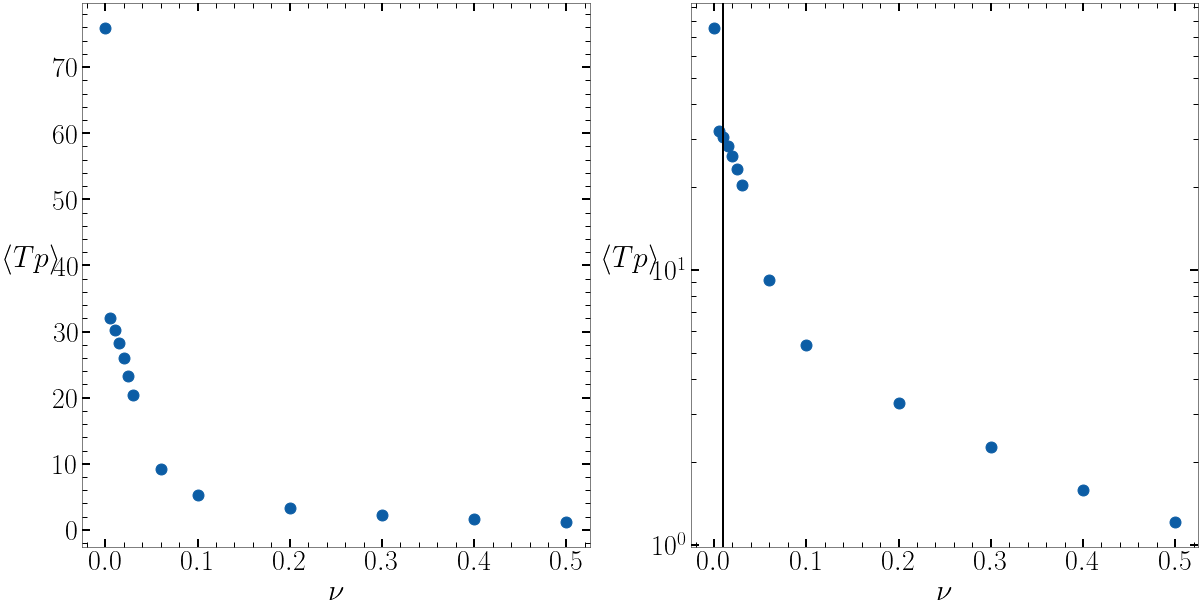

In [ ]:
Tndist = np.zeros((len(folderpath),nbins, 2))
Tnstat = np.zeros(len(folderpath))
Tnonzero = np.zeros(len(folderpath))
Tmean = np.zeros(len(folderpath))
Tndatafit = np.zeros((len(folderpath),2,2))

NCURVES = len(folderpath)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results):
    Tndist[j] = Tndist_j
    Tndatafit[j] = Tndatafit_j
    Tnstat[j] = Tnstat_j    
    Tnonzero[j] = Tnzero_j
    Tmean[j] = mean_j
    ax1.plot(Tndist[j, :,0][Tndist[j, :,1] != 1],Tndist[j, :,1][Tndist[j, :,1] != 1], color = colors[j], linewidth=4, markersize=6, mfc="none", label = f"{Tvar[j]}\nb = {-Tnstat[j]:.2f}") 
    ax1.plot(Tndatafit[j,:, 0], Tndatafit[j, :,1], color = 'k', linestyle = '--', linewidth = 3)
    ax2.scatter(Tvar[j], -Tnstat[j], color = colors[j], s = 120)
            
                
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('Tp', fontsize=30)
ax1.set_ylabel('P(Tp) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.scatter(Tvar, Tnonzero, s = 120)
ax1.set_xlabel(r'$\nu$', fontsize=30)
ax1.set_ylabel(r'$Tp_{max}$', fontsize = 30, rotation = 0,labelpad= 20)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.scatter(Tvar, Tnonzero, s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$Tp_{max}$', fontsize = 30, rotation = 0,labelpad= 20)
ax2.set_yscale('log')
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

plt.figure(figsize = (20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

ax1.scatter(Tvar, Tmean, s = 120)
ax1.set_xlabel(r'$\nu$', fontsize=30)
ax1.set_ylabel(r'$\langle Tp \rangle$', fontsize = 30, rotation = 0,labelpad= 20)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.scatter(Tvar, Tmean, s = 120)
ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\langle Tp \rangle$', fontsize = 30, rotation = 0,labelpad= 20)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
ax2.set_yscale("log")
plt.show()

## Evolution de PDF(s) en fonction du temps

In [ ]:
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD5n12"
nbins = 50

nmin = 2
nmax = 30


In [ ]:
param = read_parameters(folderpath)
nu = param[2]
lengthtab = L1 * L2

data = read_gz_with_pandas(f"{folderpath}/trans_histosize.gz")
nbhisto = int(len(data)/(L1 * L2))
print(nbhisto)
data = np.reshape(data, (nbhisto, (L1 * L2 + 1)) )

selected_points = [0,1,2,3,4,5, 6, 7, 8, 9, 49, 499]
time = np.array([param[-1][2] * (i+1) for i in range(int(param[-1][1]/param[-1][2]))])
# time = time[selected_points]

50


In [ ]:
def process_size_bis(histo, Lengthtab, nbins, nmin, nmax):

    last_non_zero = np.nonzero(histo)[0]
    
    mean = np.sum(histo * np.arange(len(histo)))/np.sum(histo)
    
    ndatafit, ndistloglog, nstat = mainfct(histo, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean

In [ ]:
Tnmin = np.array([nmin] * nbhisto)
Tnmax = np.array([nmax] * nbhisto)

results = Parallel(n_jobs=-1)(delayed(process_size_bis)(histo, lengthtab, nbins, nmin, nmax)
                                  for (histo, nmin, nmax) in zip(data, Tnmin, Tnmax))

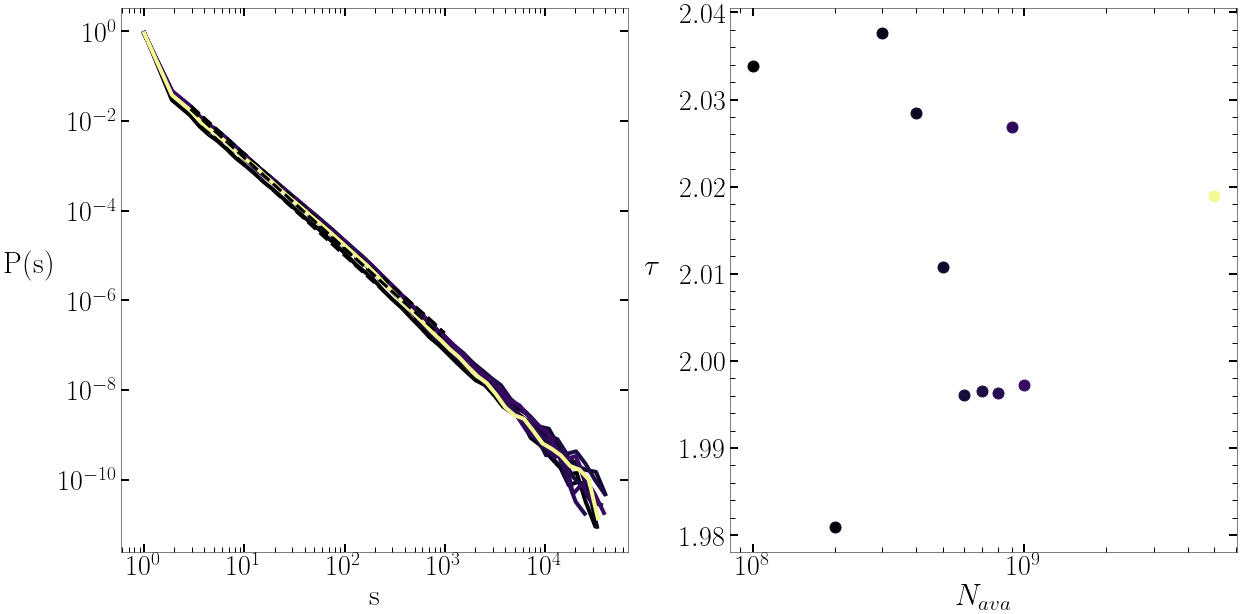

In [ ]:
Tndist = np.zeros((nbhisto,nbins, 2))
Tnstat = np.zeros(nbhisto)
Tnonzero = np.zeros(nbhisto)
Tmean = np.zeros(nbhisto)
Tndatafit = np.zeros((nbhisto,2,2))

NCURVES = nbhisto
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results):
    if j in selected_points:
        Tndist[j] = Tndist_j
        Tndatafit[j] = Tndatafit_j
        Tnstat[j] = Tnstat_j    
        Tnonzero[j] = Tnzero_j
        Tmean[j] = mean_j
        ax1.plot(Tndist[j, :,0][Tndist[j, :,1] != 1],Tndist[j, :,1][Tndist[j, :,1] != 1], color = colors[j], linewidth=4, markersize=6, mfc="none") 
        ax1.plot(Tndatafit[j,:, 0], Tndatafit[j, :,1], color = 'k', linestyle = '--', linewidth = 3)
        ax2.scatter( time[j], -Tnstat[j], color = colors[j], s = 120)
            
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xscale("log")
ax2.set_xlabel(macros['Nava'], fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

## Evolution de PDF de l'inter-time en fonction du temps

In [ ]:
folderpath = "/data1/DATA_Duplat/Brut/PDF/PD5n10"

nbins = 1000
data = read_gz_with_pandas(f"{folderpath}/trans_histoitime.gz")
param = read_parameters(folderpath)
nu = param[2]
lim_trans = param[-1][1]
delta_trans = param[-1][2]
nbhisto = int(lim_trans/delta_trans)



In [ ]:
histo = np.reshape(data, (nbhisto, nbins))
bins = np.logspace(np.log10(10**-12), np.log10(2), nbins + 1)
bin_centers = np.array([(bins[:-1] + bins[1:]) / 2] * nbhisto)

mean =  np.array([np.sum(histo[i] * bin_centers[i]) / np.sum(histo[i]) for i in range(nbhisto)])

norm_histo = np.array([histo[i]/((np.diff(bins)) * np.sum(histo[i])) for i in range(nbhisto)])
norm_histo = np.array([norm_histo[i] * mean[i] for i in range(nbhisto)])

norm_bin_centers = np.array([bin_centers[i]/mean[i] for i in range(nbhisto)])

# selected_points = [0, 1, 3, 5, 7, 9, 11, 50,  100, 450, 499]
# selected_points = [0,1,2,3,4,5,10, 20,30,40,49]
selected_points = [0,1,2,3,4,5, 7, 8, 9]
norm_histo = norm_histo[selected_points]
norm_bin_centers = norm_bin_centers[selected_points]

time = np.array([param[-1][2] * (i+1) for i in range(int(param[-1][1]/param[-1][2]))])
time = time[selected_points]

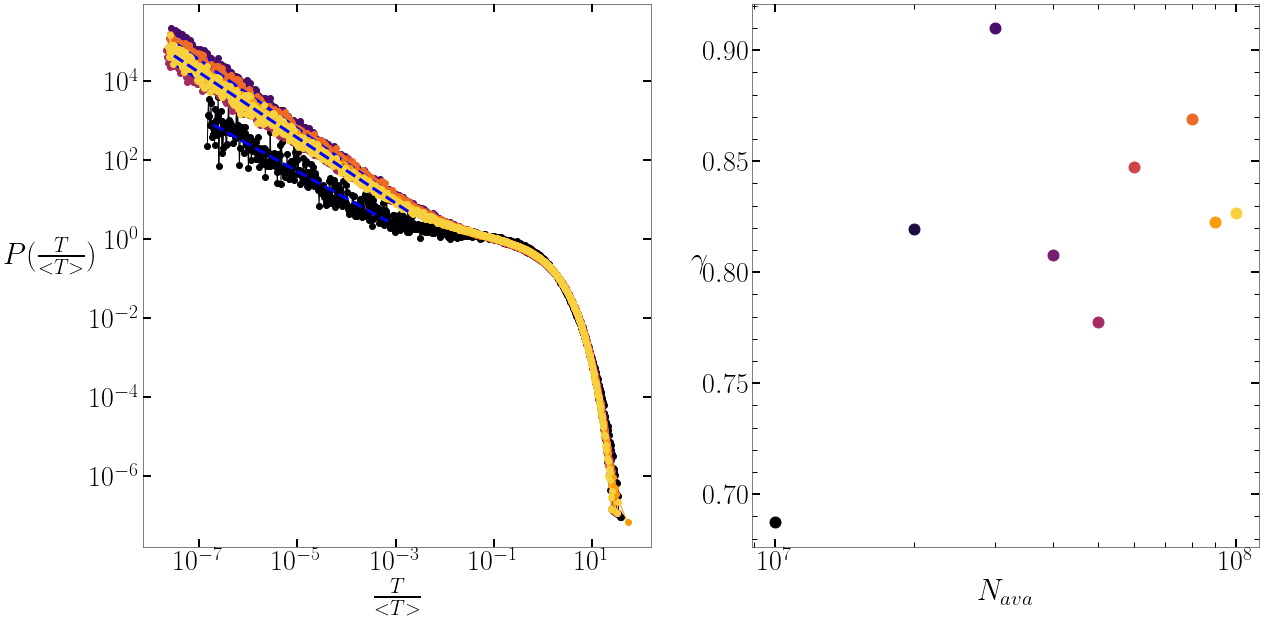

In [ ]:

Tnmin = np.array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10])
Tnmax = np.array([300, 300, 400, 400, 400, 350, 400, 400, 400, 400, 400])

NCURVES = len(norm_histo)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (bins, histo) in enumerate(zip(norm_bin_centers, norm_histo)):

    ax1.plot(bins[histo!=0], histo[histo!=0], color = colors[j], marker = "o")
    
    try:
        popt2, _ = curve_fit(powerlaw2, np.log(bins[Tnmin[j]:Tnmax[j]][histo[Tnmin[j]:Tnmax[j]]!=0]), np.log(histo[Tnmin[j]:Tnmax[j]][histo[Tnmin[j]:Tnmax[j]]!=0]))
        a2,b2 = popt2
        yfit2 = np.exp(powerlaw2(np.log(bins[Tnmin[j]:Tnmax[j]]), *popt2))
        
        ax1.plot(bins[Tnmin[j]:Tnmax[j]], yfit2, linestyle = "--", color = 'b', linewidth = 3)
        
        ax2.scatter(time[j], -b2, color  = colors[j], s = 120)
    
    except ValueError:
        continue
    
    

ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$N_{ava}$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.set_xscale('log')
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()